In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 

# processadores
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# modelos
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# metricas
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from sklearn.metrics import silhouette_score, make_scorer
from sklearn.decomposition import PCA

# variaveis globais
PATH_DF_RECOMMENDED = '../data/processed/df_recommender.csv'


In [2]:
df = pd.read_csv(PATH_DF_RECOMMENDED,  encoding='utf-8')
df = df.drop(columns=['Unnamed: 0'])

## Obejtivo

- analisar as features de audios 
1. analisar clueters das features de audios
2. fazer a contagem de frequencia dos estilos das bandas por cluster e analisar



In [3]:
features_audio = [
    'tempo_bpm',
    'rms_mean', 'rms_std',
    'zcr_mean', 'zcr_std',
    'spectral_centroid_mean', 'spectral_centroid_std',
    'spectral_bandwidth_mean', 'spectral_bandwidth_std',
    'spectral_rolloff_mean', 'spectral_rolloff_std',
    'spectral_flatness_mean', 'spectral_flatness_std',
    'mfcc_01_mean', 'mfcc_02_mean', 'mfcc_03_mean', 'mfcc_04_mean',
    'mfcc_05_mean', 'mfcc_06_mean', 'mfcc_07_mean', 'mfcc_08_mean',
    'mfcc_09_mean', 'mfcc_10_mean', 'mfcc_11_mean', 'mfcc_12_mean',
    'mfcc_13_mean',
    'chroma_01_mean', 'chroma_02_mean', 'chroma_03_mean', 'chroma_04_mean',
    'chroma_05_mean', 'chroma_06_mean', 'chroma_07_mean', 'chroma_08_mean',
    'chroma_09_mean', 'chroma_10_mean', 'chroma_11_mean', 'chroma_12_mean',
    'onset_strength_mean', 'onset_strength_std',
]

target = 'ESTILO_MUSICAL'
cols = features_audio + [target,'estilo','ID_ARTISTA']

audios = df.copy()
audios = audios[cols]


## Modelos

In [4]:
# descobrindo o melhor K para os modelos
# pipeline 

X = audios[features_audio]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K_RANGE = range(2, 13)

# ── K-Means: Inércia + Silhouette ─────────────────────────
inertias      = []
silhouettes_km = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes_km.append(silhouette_score(X_scaled, labels))

In [5]:
bics = []
aics = []

for k in K_RANGE:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

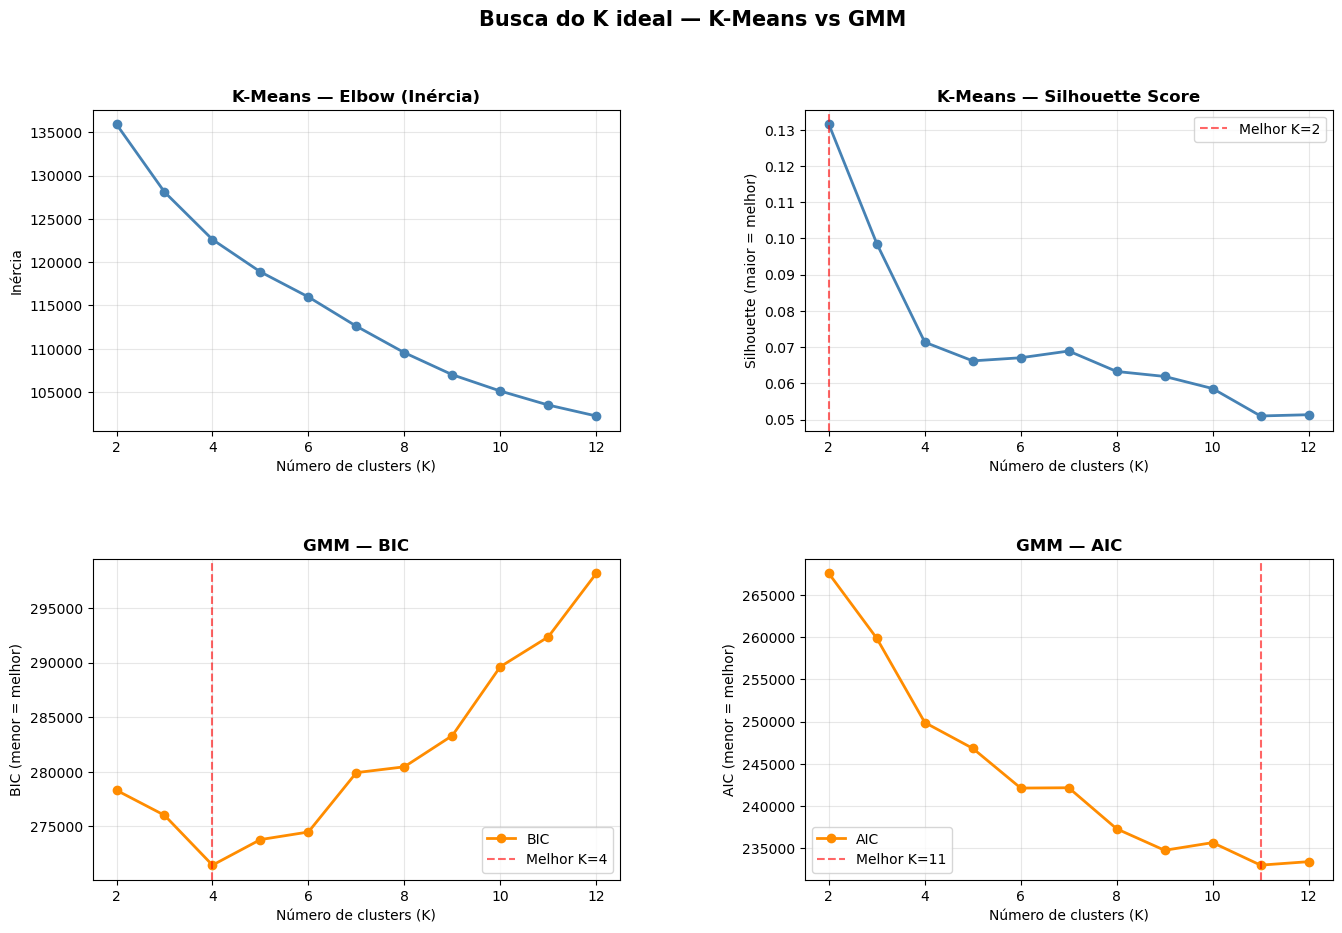

RESUMO — K sugerido por cada critério
  K-Means  │ Silhouette  │ K = 2
  GMM      │ BIC         │ K = 4
  GMM      │ AIC         │ K = 11


In [6]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Busca do K ideal — K-Means vs GMM', fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

ks = list(K_RANGE)

# 1. Elbow
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ks, inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_title('K-Means — Elbow (Inércia)', fontweight='bold')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inércia')
ax1.grid(True, alpha=0.3)

# 2. Silhouette K-Means
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ks, silhouettes_km, 'o-', color='steelblue', linewidth=2)
ax2.set_title('K-Means — Silhouette Score', fontweight='bold')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Silhouette (maior = melhor)')
ax2.grid(True, alpha=0.3)
# Marca o melhor K
best_k_sil = ks[np.argmax(silhouettes_km)]
ax2.axvline(best_k_sil, color='red', linestyle='--', alpha=0.6, label=f'Melhor K={best_k_sil}')
ax2.legend()

# 3. BIC
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(ks, bics, 'o-', color='darkorange', linewidth=2, label='BIC')
ax3.set_title('GMM — BIC', fontweight='bold')
ax3.set_xlabel('Número de clusters (K)')
ax3.set_ylabel('BIC (menor = melhor)')
ax3.grid(True, alpha=0.3)
best_k_bic = ks[np.argmin(bics)]
ax3.axvline(best_k_bic, color='red', linestyle='--', alpha=0.6, label=f'Melhor K={best_k_bic}')
ax3.legend()

# 4. AIC
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(ks, aics, 'o-', color='darkorange', linewidth=2, label='AIC')
ax4.set_title('GMM — AIC', fontweight='bold')
ax4.set_xlabel('Número de clusters (K)')
ax4.set_ylabel('AIC (menor = melhor)')
ax4.grid(True, alpha=0.3)
best_k_aic = ks[np.argmin(aics)]
ax4.axvline(best_k_aic, color='red', linestyle='--', alpha=0.6, label=f'Melhor K={best_k_aic}')
ax4.legend()

plt.show()

# ── Resumo no console ─────────────────────────────────────
print("=" * 45)
print("RESUMO — K sugerido por cada critério")
print("=" * 45)
print(f"  K-Means  │ Silhouette  │ K = {best_k_sil}")
print(f"  GMM      │ BIC         │ K = {best_k_bic}")
print(f"  GMM      │ AIC         │ K = {best_k_aic}")
print("=" * 45)

In [7]:
print('quantidade de estilos:', df.ESTILO_MUSICAL.nunique())
print('estilos unicos:', df.ESTILO_MUSICAL.unique())
# - por ter muitos estilos e ainda sub generos de estilos os clusters provavelmente vao apresentar grupos com muitos estilos
# - por essa razao , que a analise vai ser em entender a familia sonora de cada cluester

quantidade de estilos: 35
estilos unicos: ['Sertanejo' 'Pagode' 'Sertanejo Universitário' 'MPB'
 'Músicas Internacionais' 'Banda Baile' 'Ritmos Variados' 'Eletrônica'
 'Pop' 'Samba' 'Pop Rock' 'Rock' 'Reggae' 'Blues' 'Country' 'Forró' 'Jazz'
 'Cover/Tributo' 'DJ' 'Black Music' 'Gospel' 'Folk' 'Música Clássica'
 'RAP' 'Funk' 'Soul' 'Bossa Nova' 'Brasilidades' 'Carnaval'
 'Músicas para Crianças' 'Axé' 'Chorinho' nan 'Música Latina'
 'Indie/Alternativo' 'Piseiro']


In [8]:
# pipeline 

K_KM = 5
K_GMM = 4

pipe_km = Pipeline([
    ('scaler', StandardScaler()),
    ('cluster', KMeans(n_clusters=K_KM, random_state=42, n_init='auto'))
])

pipe_gmm = Pipeline([
    ('scaler', StandardScaler()),
    ('cluster', GaussianMixture(n_components=K_GMM, random_state=42))
])

In [9]:
# treinando
labels_km  = pipe_km.fit_predict(X)

pipe_gmm.fit(X)
labels_gmm = pipe_gmm['cluster'].predict(X)


c:\Users\pedro\miniconda3\envs\project_ml\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GaussianMixture was fitted without feature names
  warnings.warn(


In [10]:
# ── Adicionar labels no dataframe ─────────────────────────
audios['cluster_km']  = labels_km
audios['cluster_gmm'] = labels_gmm

# ── Sanidade — checar distribuição dos clusters ───────────
print("=" * 40)
print(f"K-Means (K={K_KM}) — distribuição")
print("=" * 40)
print(audios['cluster_km'].value_counts().sort_index())

print()
print("=" * 40)
print(f"GMM (K={K_GMM}) — distribuição")
print("=" * 40)
print(audios['cluster_gmm'].value_counts().sort_index())

K-Means (K=5) — distribuição
cluster_km
0     784
1    1057
2     500
3     664
4     885
Name: count, dtype: int64

GMM (K=4) — distribuição
cluster_gmm
0    3803
3      87
Name: count, dtype: int64


In [11]:
# grafico PCA 2D

X_scaled = pipe_km['scaler'].transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)


PC1 explica: 19.4%
PC2 explica: 12.3%
Total:       31.7%


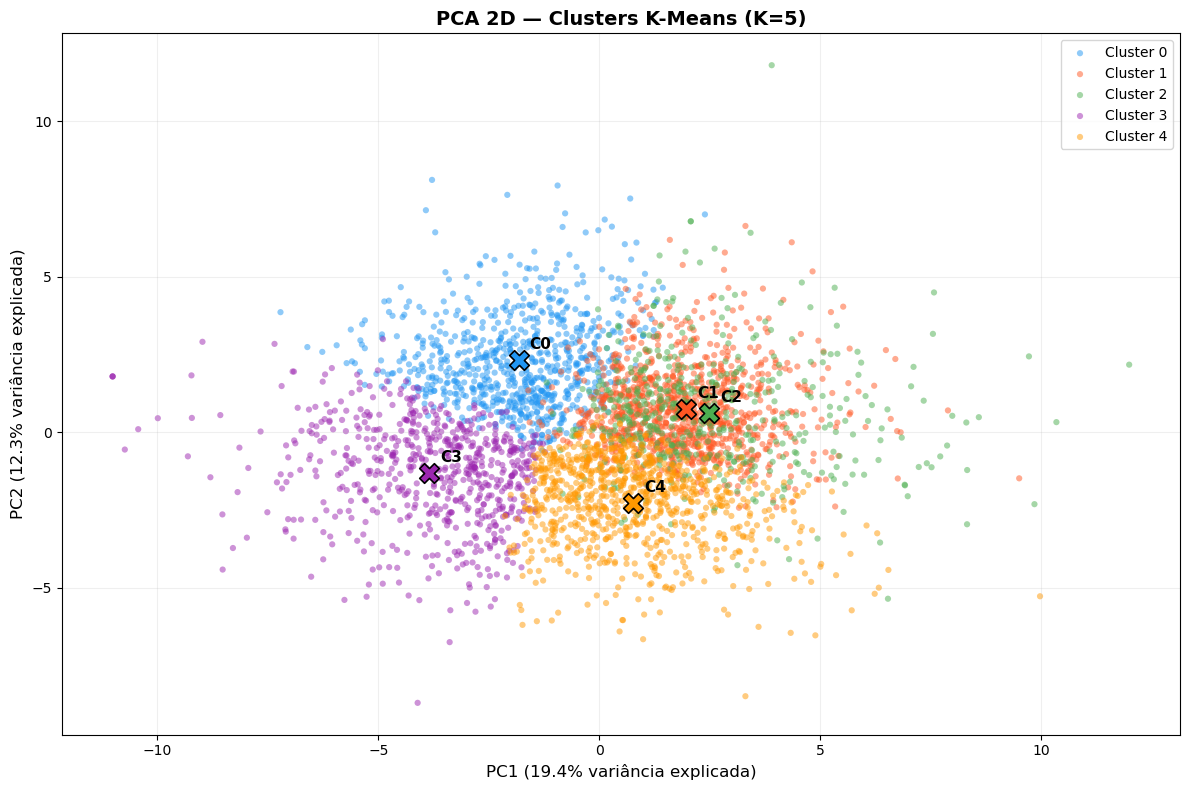

In [12]:
# variancia explicada 
var1, var2 = pca.explained_variance_ratio_ * 100
print(f"PC1 explica: {var1:.1f}%")
print(f"PC2 explica: {var2:.1f}%")
print(f"Total:       {var1 + var2:.1f}%")


# plot 
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
LABELS = [f'Cluster {i}' for i in range(5)]

fig, ax = plt.subplots(figsize=(12, 8))

for i in range(5):
    mask = labels_km == i
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=COLORS[i],
        label=LABELS[i],
        alpha=0.5,
        s=20,
        edgecolors='none'
    )

# Centroides no espaço PCA
centroids_pca = pca.transform(pipe_km['cluster'].cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.scatter(cx, cy, c=COLORS[i], s=200, marker='X',
               edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                xytext=(8, 8), fontsize=11, fontweight='bold')

ax.set_xlabel(f'PC1 ({var1:.1f}% variância explicada)', fontsize=12)
ax.set_ylabel(f'PC2 ({var2:.1f}% variância explicada)', fontsize=12)
ax.set_title('PCA 2D — Clusters K-Means (K=5)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

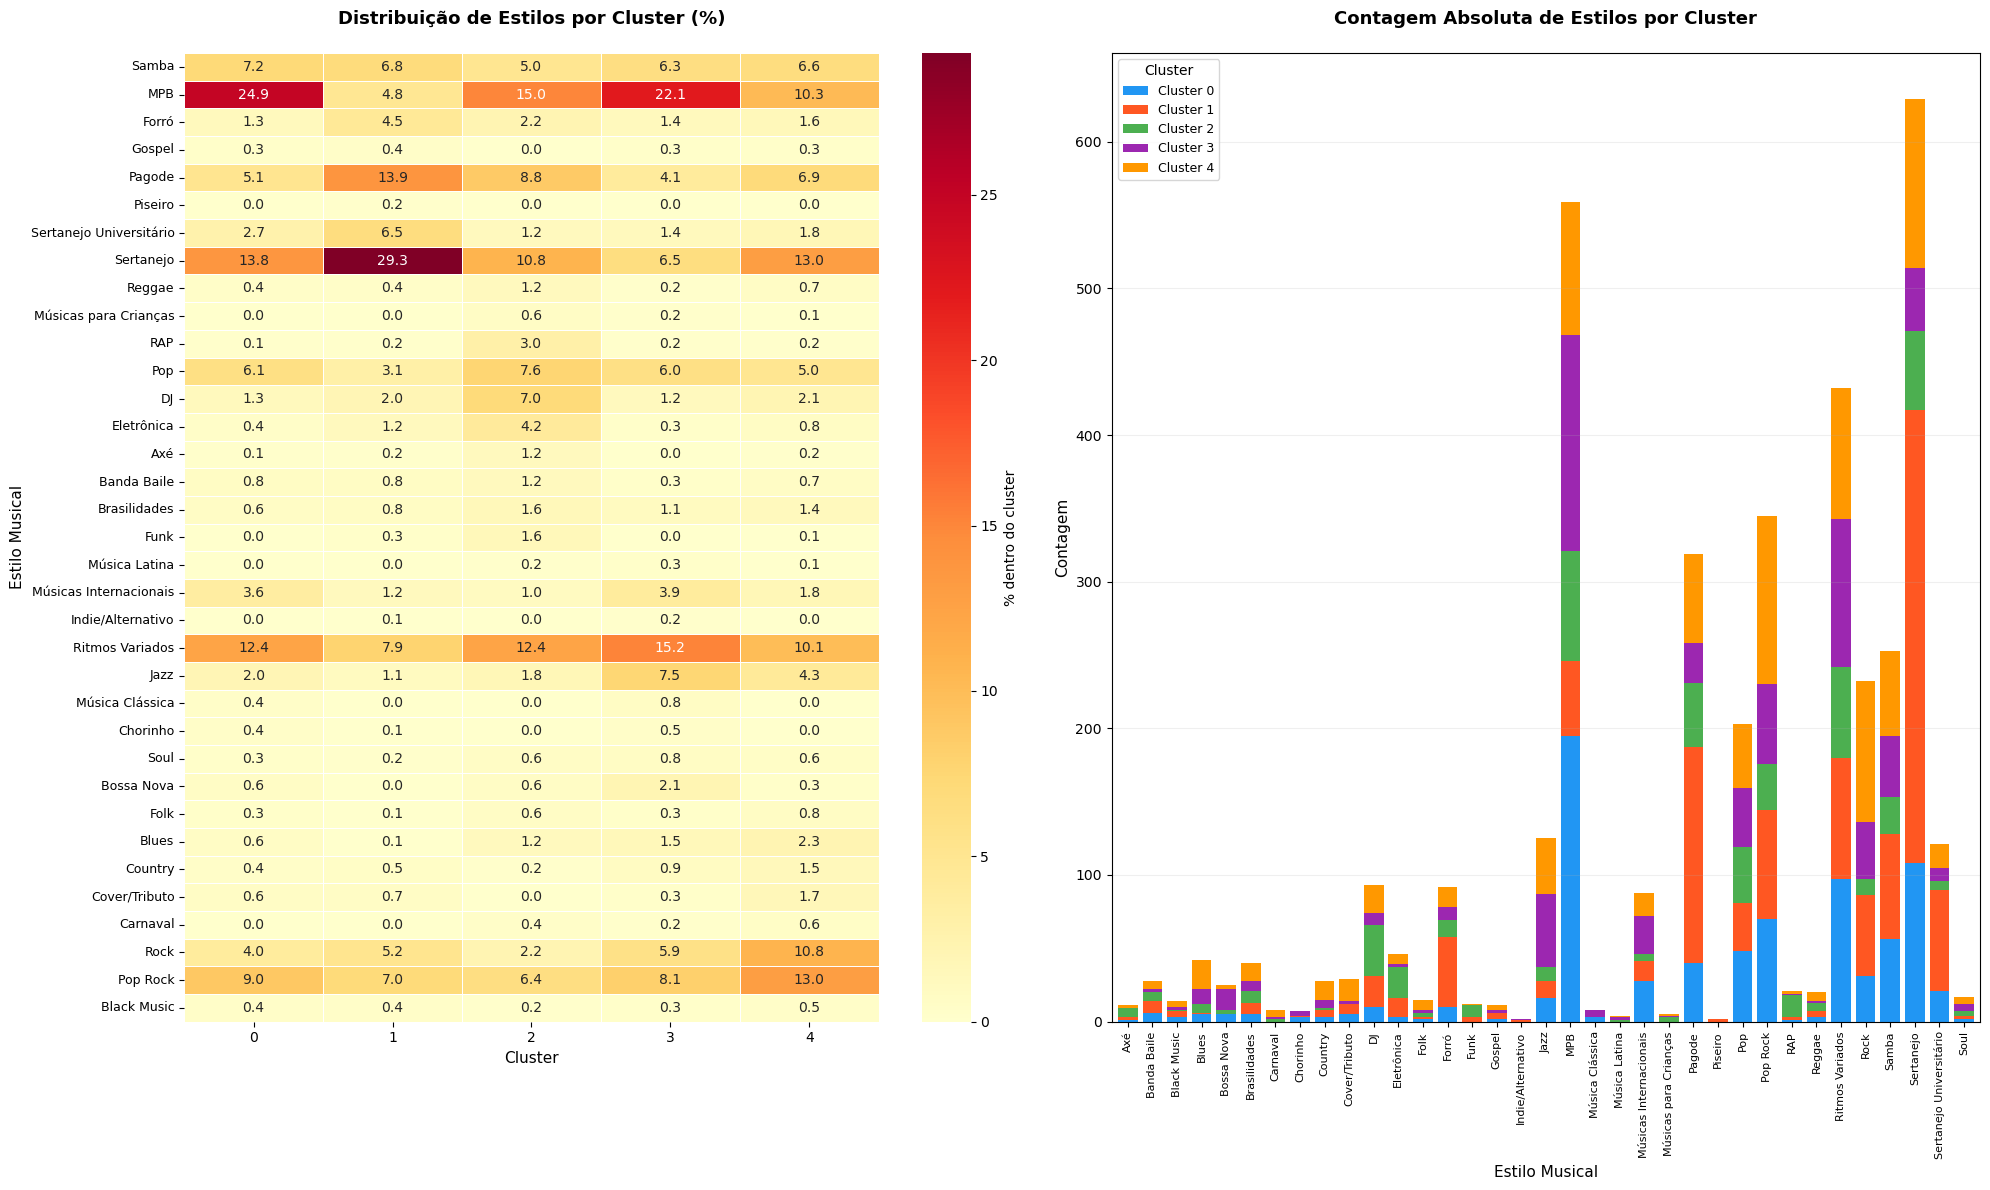

In [13]:
contagem = (
    audios.groupby(['cluster_km', 'ESTILO_MUSICAL'])
    .size()
    .reset_index(name='count')
)

# Pivot para heatmap
pivot = contagem.pivot(index='ESTILO_MUSICAL', columns='cluster_km', values='count').fillna(0)

# Versão normalizada por cluster (% dentro de cada cluster)
pivot_pct = pivot.div(pivot.sum(axis=0), axis=1) * 100

# ── Ordenar estilos pelo cluster dominante ────────────────
pivot_pct['cluster_dominante'] = pivot_pct.idxmax(axis=1)
pivot_pct = pivot_pct.sort_values('cluster_dominante')
pivot_pct = pivot_pct.drop(columns='cluster_dominante')

# ── Plot 1 — Heatmap percentual ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

sns.heatmap(
    pivot_pct,
    ax=axes[0],
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': '% dentro do cluster'}
)
axes[0].set_title('Distribuição de Estilos por Cluster (%)\n', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].set_ylabel('Estilo Musical', fontsize=11)
axes[0].tick_params(axis='y', labelsize=9)

# ── Plot 2 — Barplot empilhado (contagem absoluta) ────────
pivot_plot = pivot.copy()
pivot_plot.columns = [f'Cluster {c}' for c in pivot_plot.columns]

COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

pivot_plot.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=COLORS,
    edgecolor='none',
    width=0.8
)
axes[1].set_title('Contagem Absoluta de Estilos por Cluster\n', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Estilo Musical', fontsize=11)
axes[1].set_ylabel('Contagem', fontsize=11)
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].legend(title='Cluster', fontsize=9)
axes[1].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()



In [14]:
# ── Resumo textual — top 5 estilos por cluster ───────────
print("=" * 50)
print("TOP 5 ESTILOS POR CLUSTER")
print("=" * 50)
for cluster in sorted(audios['cluster_km'].unique()):
    top5 = (
        audios[audios['cluster_km'] == cluster]['ESTILO_MUSICAL']
        .value_counts()
        .head(5)
    )
    print(f"\nCluster {cluster}:")
    for estilo, n in top5.items():
        display(f"  {estilo:<30} {n:>4}")

TOP 5 ESTILOS POR CLUSTER

Cluster 0:


'  MPB                             195'

'  Sertanejo                       108'

'  Ritmos Variados                  97'

'  Pop Rock                         70'

...

'  Pop Rock                        115'

'  Sertanejo                       115'

'  Rock                             96'

'  MPB                              91'

'  Ritmos Variados                  89'

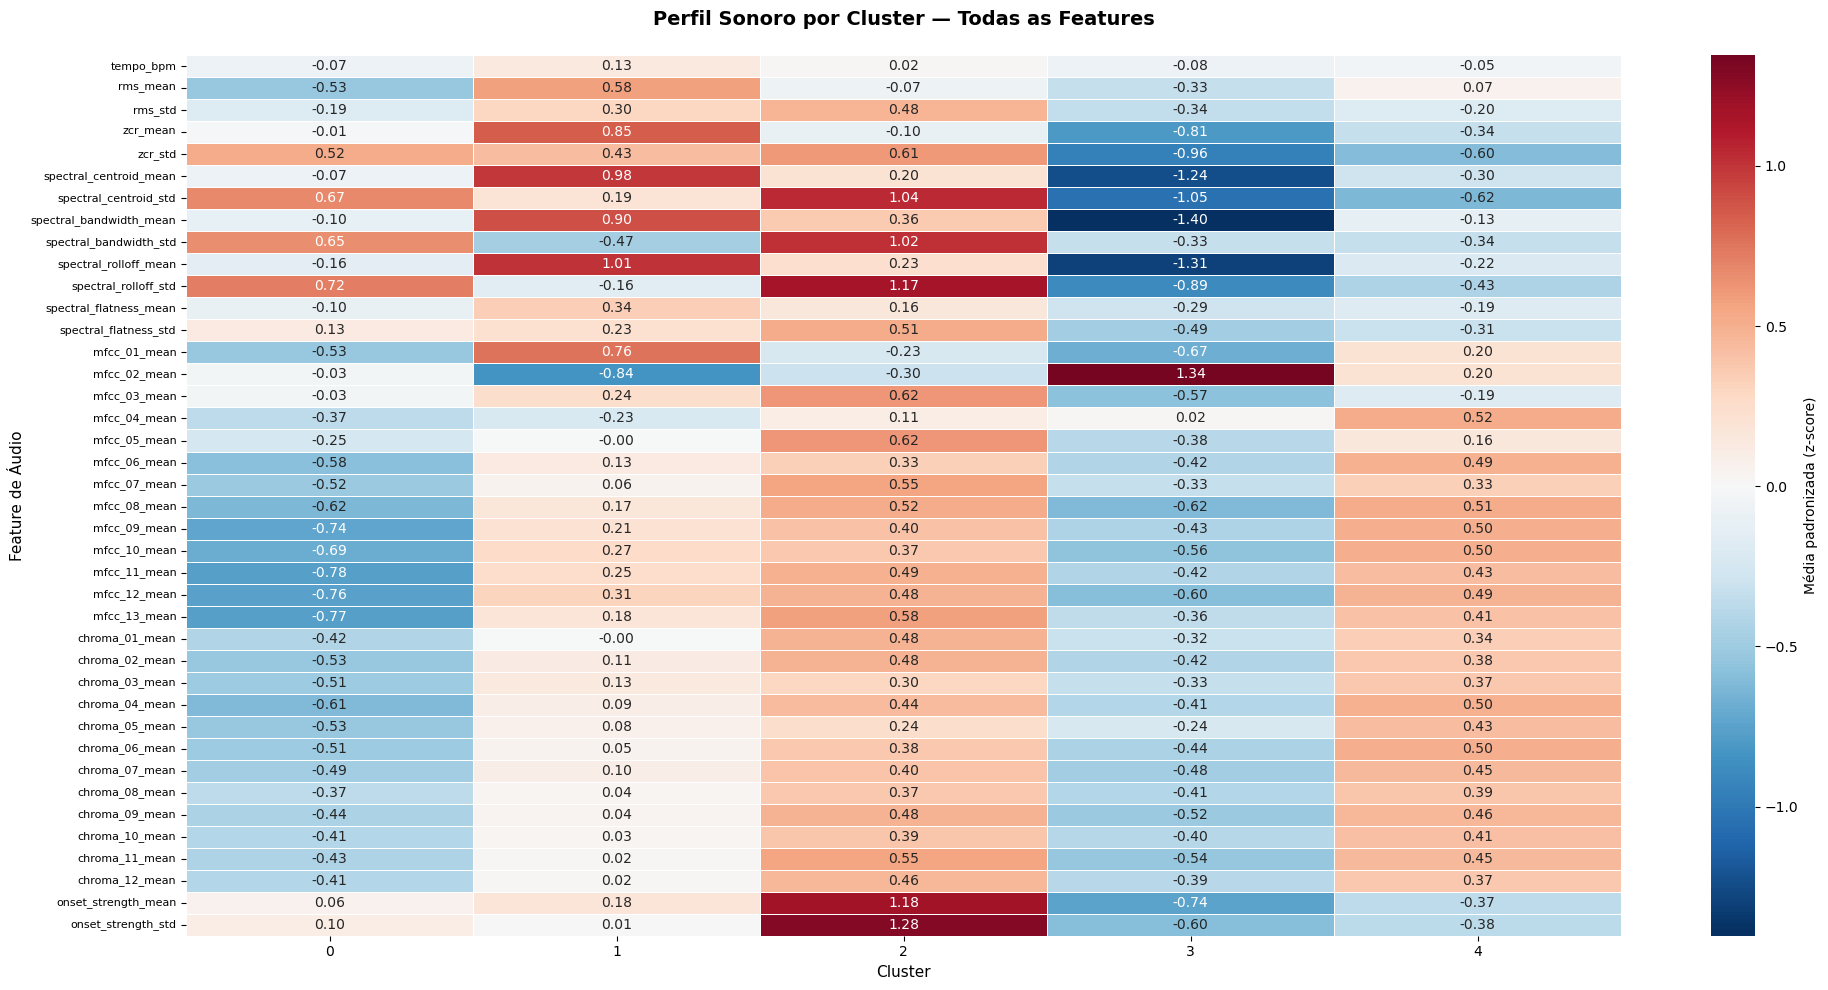

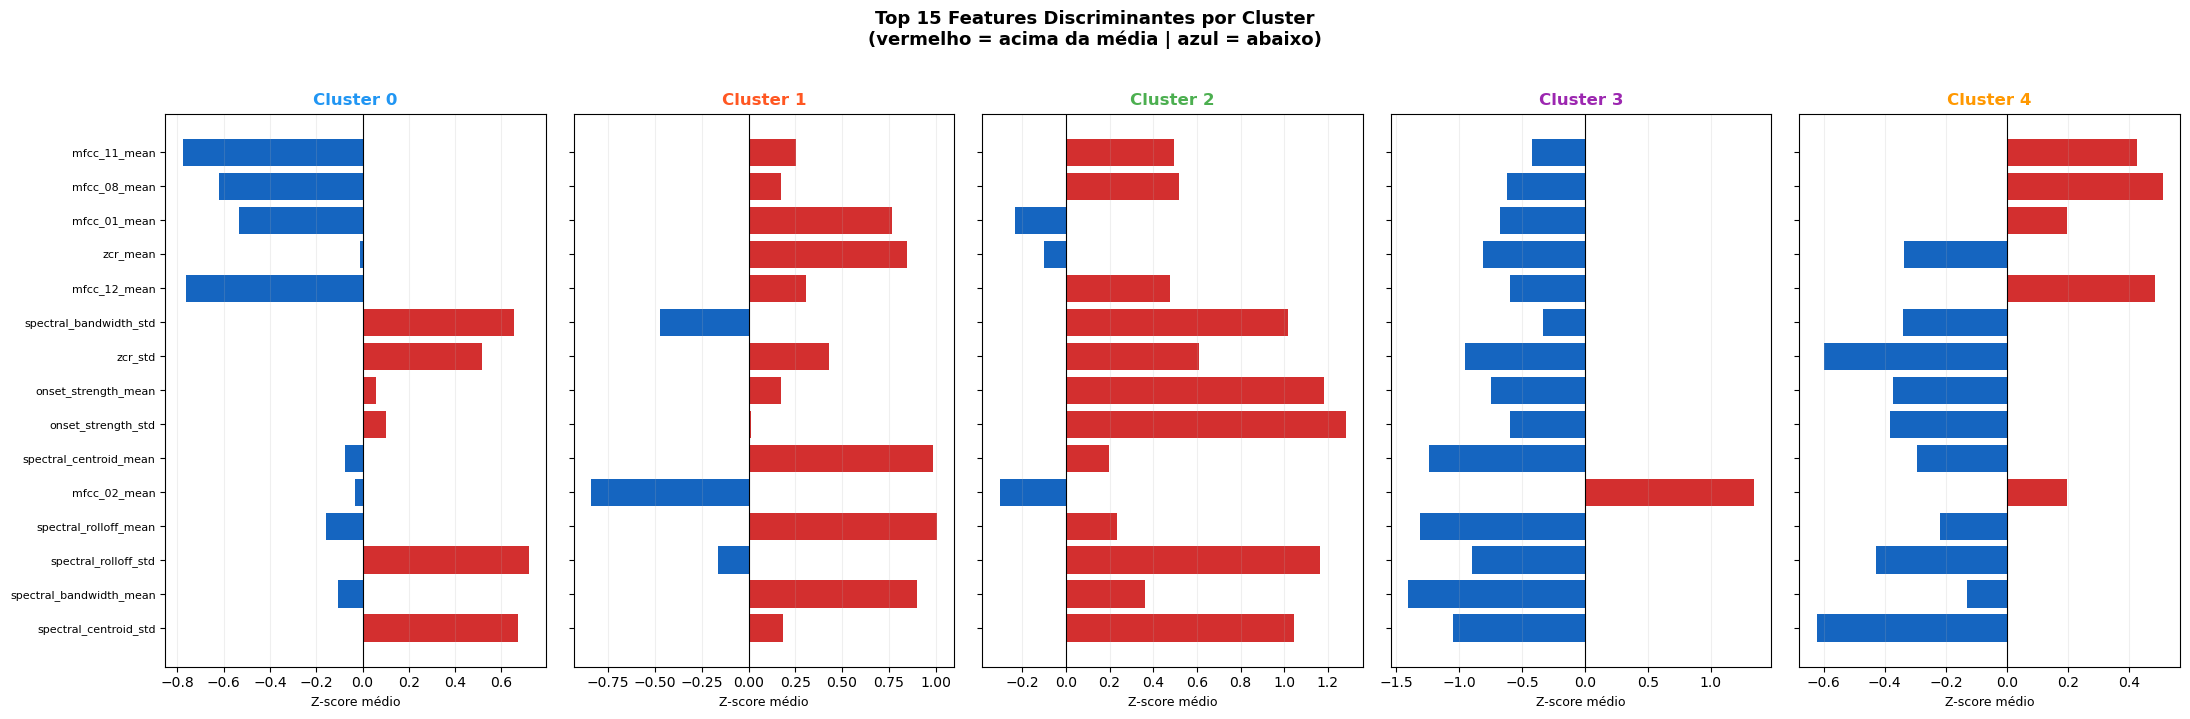

PERFIL SONORO — TOP 5 FEATURES ALTAS/BAIXAS POR CLUSTER

Cluster 0:
  ALTO  → spectral_rolloff_std, spectral_centroid_std, spectral_bandwidth_std
  BAIXO → mfcc_12_mean, mfcc_13_mean, mfcc_11_mean

Cluster 1:
  ALTO  → spectral_rolloff_mean, spectral_centroid_mean, spectral_bandwidth_mean
  BAIXO → mfcc_04_mean, spectral_bandwidth_std, mfcc_02_mean

Cluster 2:
  ALTO  → onset_strength_std, onset_strength_mean, spectral_rolloff_std
  BAIXO → zcr_mean, mfcc_01_mean, mfcc_02_mean

Cluster 3:
  ALTO  → mfcc_02_mean, mfcc_04_mean, tempo_bpm
  BAIXO → spectral_centroid_mean, spectral_rolloff_mean, spectral_bandwidth_mean

Cluster 4:
  ALTO  → mfcc_04_mean, mfcc_08_mean, mfcc_10_mean
  BAIXO → spectral_rolloff_std, zcr_std, spectral_centroid_std


In [15]:
# ── Média de cada feature por cluster (dados escalados) ───
X_scaled = pipe_km['scaler'].transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=features_audio)
df_scaled['cluster_km'] = labels_km

media_por_cluster = df_scaled.groupby('cluster_km')[features_audio].mean()

# ── Plot 1 — Heatmap geral de todas as features ───────────
fig, ax = plt.subplots(figsize=(20, 10))

sns.heatmap(
    media_por_cluster.T,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Média padronizada (z-score)'}
)
ax.set_title('Perfil Sonoro por Cluster — Todas as Features\n',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylabel('Feature de Áudio', fontsize=11)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('perfil_sonoro_completo.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2 — Top features discriminantes por cluster ──────
# Features com maior variância entre clusters = mais discriminantes
variancia_entre_clusters = media_por_cluster.var(axis=0).sort_values(ascending=False)
top_features = variancia_entre_clusters.head(15).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(22, 7), sharey=True)
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

for i, ax in enumerate(axes):
    vals = media_por_cluster.loc[i, top_features]
    colors_bar = ['#d32f2f' if v > 0 else '#1565C0' for v in vals]
    
    ax.barh(top_features, vals, color=colors_bar, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Cluster {i}', fontsize=12, fontweight='bold', color=COLORS[i])
    ax.grid(True, alpha=0.2, axis='x')
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlabel('Z-score médio', fontsize=9)

fig.suptitle('Top 15 Features Discriminantes por Cluster\n(vermelho = acima da média | azul = abaixo)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# ── Resumo textual — features mais altas e mais baixas ────
print("=" * 55)
print("PERFIL SONORO — TOP 5 FEATURES ALTAS/BAIXAS POR CLUSTER")
print("=" * 55)
for i in range(5):
    perfil = media_por_cluster.loc[i].sort_values(ascending=False)
    print(f"\nCluster {i}:")
    print("  ALTO  →", ', '.join(perfil.head(3).index.tolist()))
    print("  BAIXO →", ', '.join(perfil.tail(3).index.tolist()))

## Nomeando os clusters

### Cluster 1 — "Brilhante / Dançante"
- Centroide alto = som brilhante/agudo. 
- Rolloff alto = energia nas frequências altas. 
- Bandwidth alto = espectro cheio e complexo. 
- O baixo std no bandwidth indica que esse brilho é consistente e estável — não varia, é uma característica permanente do som. 
Música produzida, polida, com presença forte nos agudos.

### Cluster 2 — "Percussivo / Rítmico"
- Onset strength alto = ataques sonoros fortes e marcados = percussividade alta. 
- ZCR baixo indica som tonal, não ruidoso — os ataques são limpos. 
- Energia geral baixa (mfcc_01 baixo). 
- Música com batida forte e definida mas não necessariamente alta — ritmo é o protagonista.

### Cluster 3 — "Grave / Sombrio"
- Centroide baixo = som escuro/grave. 
- Rolloff baixo = energia concentrada nas baixas frequências. 
- Bandwidth baixo = espectro estreito, som mais puro/tonal. 
- Tempo_bpm alto indica andamento rápido. Música grave, densa, acelerada — energia nas frequências baixas com ritmo acelerado.

### Cluster 4 — "Harmônico / Estável"
- MFCCs de detalhe fino altos = timbre rico em harmônicos e ressonâncias. 
- Os baixos stds espectrais indicam consistência total — o timbre não varia, é sempre igual. 
- Música com arranjo harmônico rico e sonoridade muito estável — identidade sonora forte e definida.


In [16]:
# ── Mapa de nomes dos clusters ────────────────────────────
cluster_names = {
    0: 'Eclético / Variado',
    1: 'Brilhante / Dançante',
    2: 'Percussivo / Rítmico',
    3: 'Grave / Sombrio',
    4: 'Harmônico / Estável'
}

audios['cluster_nome'] = audios['cluster_km'].map(cluster_names)

# ── Checagem final ────────────────────────────────────────
display(audios.cluster_nome.value_counts())
display(audios.head())

cluster_nome
Brilhante / Dançante    1057
Harmônico / Estável      885
Eclético / Variado       784
Grave / Sombrio          664
Percussivo / Rítmico     500
Name: count, dtype: int64

,tempo_bpm,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,...,chroma_11_mean,chroma_12_mean,onset_strength_mean,onset_strength_std,ESTILO_MUSICAL,estilo,ID_ARTISTA,cluster_km,cluster_gmm,cluster_nome
0,95.703125,0.103818,0.058848,0.064630,0.058430,1711.959657,802.407133,2159.542912,610.128848,3257.677022,...,0.133262,0.101514,1.163928,1.399856,Sertanejo,Sertanejo,14776,0,0,Eclético / Variado
1,123.046875,0.200901,0.047888,0.093274,0.044329,2562.521413,674.964171,2787.462911,433.424655,5835.133489,...,0.256088,0.396258,1.403732,1.200558,Pagode,Pagode,4201,1,0,Brilhante / Dançante
2,117.453835,0.304199,0.095733,0.077904,0.066006,2066.055385,767.979638,2432.003020,388.064763,4589.698053,...,0.290270,0.294469,1.620069,1.657517,Sertanejo Universitário,Sertanejo Universitário,13089,1,0,Brilhante / Dançante
3,89.102909,0.287212,0.077001,0.093760,0.068754,2219.161523,976.208798,2523.524456,535.897330,4850.404048,...,0.406118,0.525359,1.397120,1.320038,MPB,MPB,3739,2,0,Percussivo / Rítmico
4,69.837416,0.127254,0.084599,0.049006,0.046215,1533.562950,1050.105666,1863.555188,594.968376,3130.961082,...,0.392708,0.379018,1.500846,2.212292,MPB,MPB,18784,2,0,Percussivo / Rítmico


# Proximos passos

Fetio o cluster com o K-means vimos que ess modelo consegue encontrar os grupos de familias sonoras expondo um sintona engraçado onde as bandas se classificam com estilos nos quais 
nao batem com suas familias sonoras. 

Para melhoras o modelo de cluster e entender melhor como classificar a familia sonora de cada banda podemos `aplicar uma reducação de dimensionalidade antes`, pois atualmente o dataset possui 40 features de audios oq dificulta encontrar as distancias que separam os clusters.

Ao aplicar reducao de dimensionalidade `podemos voltar a considerar aplicar novamente o modelo de cluster GMM`. Ess modelo é muito instavale para altas dimensionalidades. Ele pode ser voltado a ser considerado por lidar bem com grupos que se misturam e `por fornecer a probabildiade entre dos grupos`, sendo util para criar rankins das bandas e mostrar a quantidade de mix de estilo que a banda tem. 

# Buscando melhorias para o modelo

oque vai ser feito
- 1. busca dos melhores hiperparametros e treino: Aglomerative Clustering, K-Means, GMM
- 2. comparacao dos resultados dos modelos: definir o melhor modelo para o proximo passo
- 3. usar Redução de Dimensionalidade para avaliar se melhora o cluster do modelo que apresentou melhor resultado
- 4. analisar outliers com DBSCAN
- 5. nomear os clusters encontrados
- 6. salvar labels na tabela de `audios`

Silhouette Score (metrics.silhouette_score): mede quão bem os pontos estão agrupados.

Calinski-Harabasz Index (metrics.calinski_harabasz_score): avalia a separação entre clusters.

Davies-Bouldin Index (metrics.davies_bouldin_score): mede a similaridade entre clusters (quanto menor, melhor).

## Passo 1.1 — Agglomerative Clustering

Busca dos melhores hiperparâmetros via `ParameterGrid`:
- `n_clusters`: 2 a 12
- `linkage`: ward, complete, average

Avaliação com 3 métricas: **Silhouette**, **Calinski-Harabasz**, **Davies-Bouldin**.

In [17]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

X_scaled_agg = StandardScaler().fit_transform(X)

results_agg = []
for params in ParameterGrid({'n_clusters': list(range(2, 13)), 'linkage': ['ward', 'complete', 'average']}):
    labels = AgglomerativeClustering(**params).fit_predict(X_scaled_agg)
    results_agg.append({
        **params,
        'silhouette':     silhouette_score(X_scaled_agg, labels),
        'calinski':       calinski_harabasz_score(X_scaled_agg, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled_agg, labels),
    })

df_agg = pd.DataFrame(results_agg)
display(df_agg.sort_values('silhouette', ascending=False).head(10))

,linkage,n_clusters,silhouette,calinski,davies_bouldin
11,complete,2,0.756613,91.894047,0.173263
22,average,2,0.756613,91.894047,0.173263
23,average,3,0.510376,83.092813,0.695966
12,complete,3,0.502442,79.139225,0.706284
24,average,4,0.492357,57.101300,0.635709
25,average,5,0.439989,44.243780,0.590840
26,average,6,0.415092,38.002389,0.675431
27,average,7,0.382782,32.464027,0.643056
28,average,8,0.349899,28.769152,0.722950
29,average,9,0.342218,25.559545,0.656835


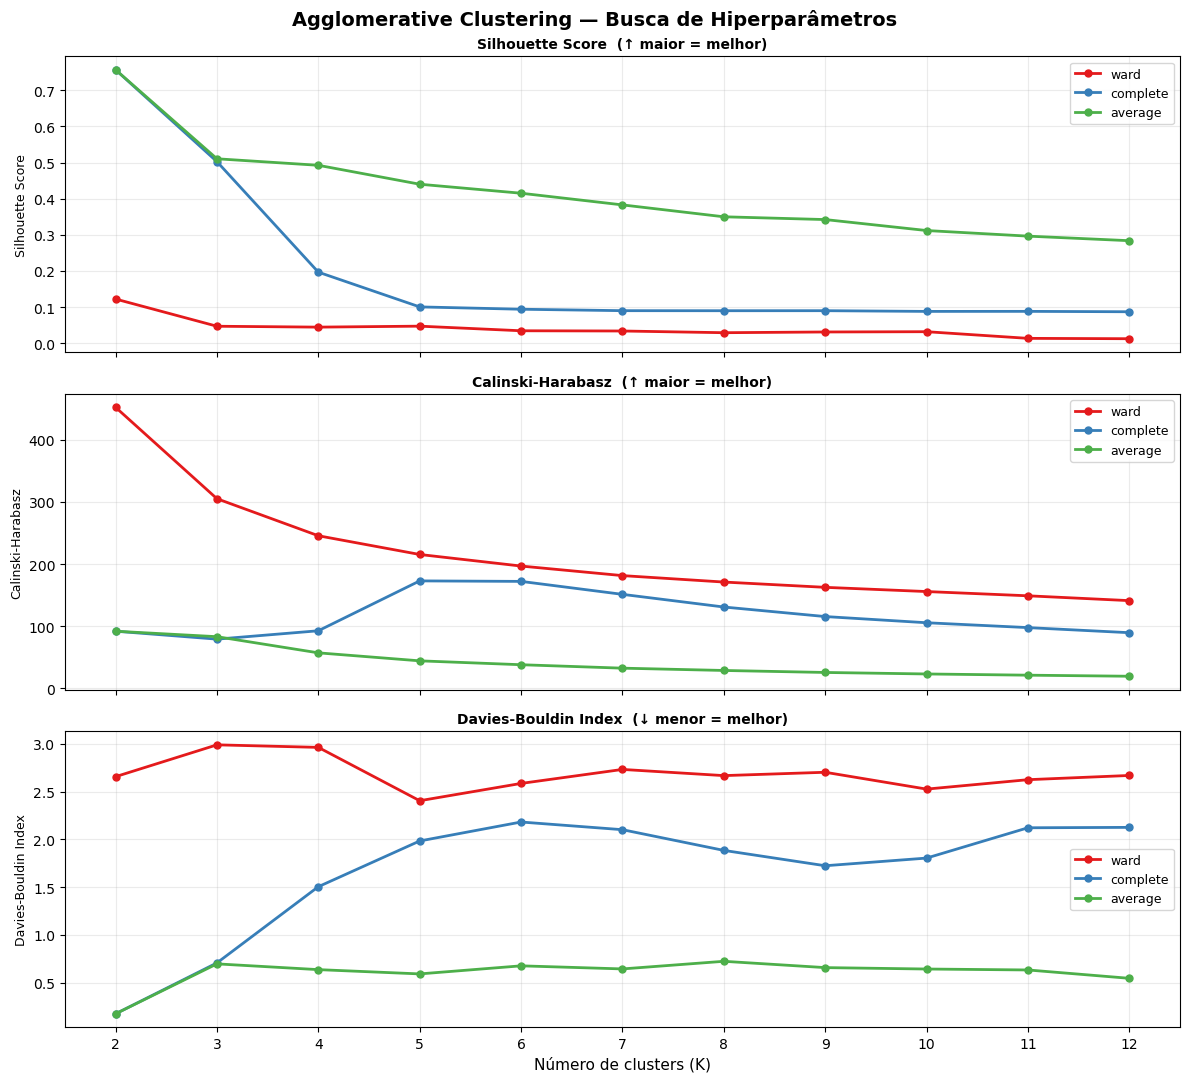

In [18]:
def plot_cluster_metrics(df_results, param_col, group_col, title):
    """Plota Silhouette, Calinski-Harabasz e Davies-Bouldin por K, agrupado por parâmetro categórico."""
    metrics = [
        ('silhouette',     'Silhouette Score',     'higher'),
        ('calinski',       'Calinski-Harabasz',    'higher'),
        ('davies_bouldin', 'Davies-Bouldin Index', 'lower'),
    ]
    groups = df_results[group_col].unique()
    colors = plt.cm.Set1.colors[:len(groups)]

    # ignora o K mínimo na busca do melhor (K=2 tende a inflar métricas artificialmente)
    min_k = df_results[param_col].min()
    df_search = df_results[df_results[param_col] > min_k]

    fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for ax, (col, label, direction) in zip(axes, metrics):
        for color, grp in zip(colors, groups):
            sub = df_results[df_results[group_col] == grp].sort_values(param_col)
            ax.plot(sub[param_col], sub[col], 'o-', label=grp, linewidth=2, markersize=5, color=color)

        ax.set_title(f'{label}  ({"↑ maior = melhor" if direction == "higher" else "↓ menor = melhor"})',
                     fontsize=10, fontweight='bold')
        ax.set_ylabel(label, fontsize=9)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel('Número de clusters (K)', fontsize=11)
    axes[-1].set_xticks(list(range(2, 13)))
    plt.tight_layout()
    plt.show()


plot_cluster_metrics(df_agg, 'n_clusters', 'linkage',
                     'Agglomerative Clustering — Busca de Hiperparâmetros')

MELHOR CONFIGURAÇÃO POR MÉTRICA — Agglomerative Clustering
  Silhouette  ↑  K= 2, linkage=complete   → 0.7566
  Calinski    ↑  K= 2, linkage=ward       → 452.0
  Davies-B    ↓  K= 2, linkage=complete   → 0.1733

Modelo treinado: K=5, linkage=complete
cluster_agg
0    1433
1     160
2      12
3       3
4    2282
Name: count, dtype: int64


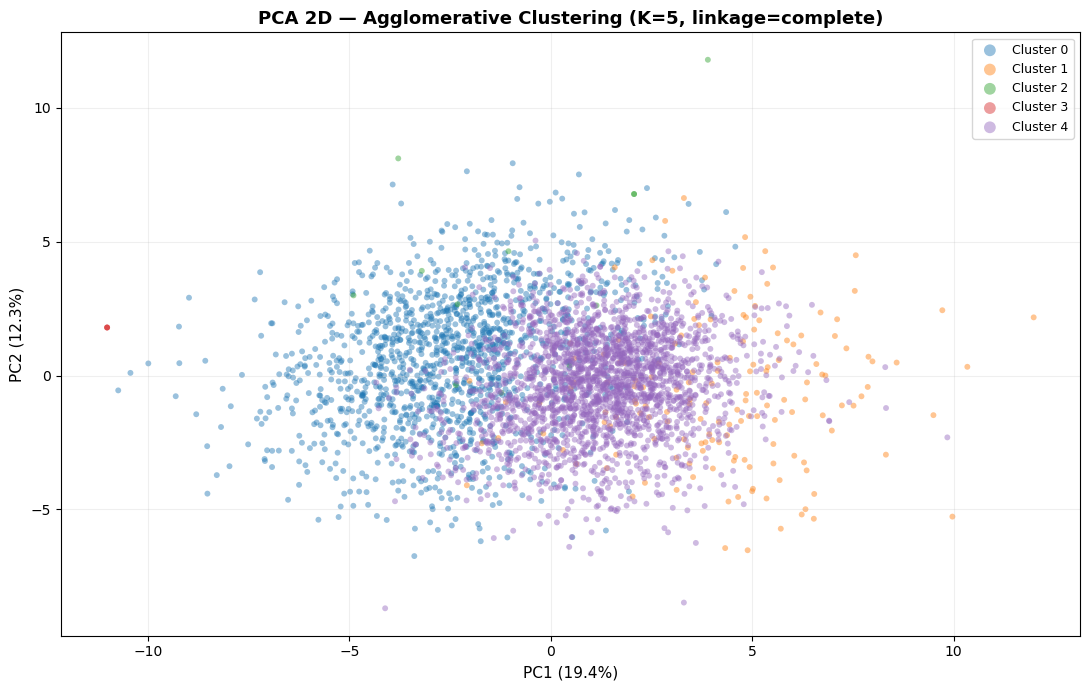

TOP 5 ESTILOS POR CLUSTER — cluster_agg

Cluster 0:


'  MPB                             321'

'  Ritmos Variados                 183'

'  Sertanejo                       150'

'  Pop Rock                        122'

...

'  Sertanejo                       469'

'  Pagode                          246'

'  MPB                             229'

'  Ritmos Variados                 228'

'  Pop Rock                        200'

In [19]:
# ── Resumo das melhores configurações ─────────────────────
best_sil = df_agg.loc[df_agg['silhouette'].idxmax()]
best_cal = df_agg.loc[df_agg['calinski'].idxmax()]
best_dbi = df_agg.loc[df_agg['davies_bouldin'].idxmin()]

print("=" * 60)
print("MELHOR CONFIGURAÇÃO POR MÉTRICA — Agglomerative Clustering")
print("=" * 60)
print(f"  Silhouette  ↑  K={int(best_sil.n_clusters):>2}, linkage={best_sil.linkage:<10} → {best_sil.silhouette:.4f}")
print(f"  Calinski    ↑  K={int(best_cal.n_clusters):>2}, linkage={best_cal.linkage:<10} → {best_cal.calinski:.1f}")
print(f"  Davies-B    ↓  K={int(best_dbi.n_clusters):>2}, linkage={best_dbi.linkage:<10} → {best_dbi.davies_bouldin:.4f}")
print("=" * 60)

# ── Funções de visualização reutilizáveis ─────────────────
def plot_pca_2d(X_scaled, labels, title, colors=None, centroids=None):
    pca_obj = PCA(n_components=2, random_state=42)
    Xp = pca_obj.fit_transform(X_scaled)
    v1, v2 = pca_obj.explained_variance_ratio_ * 100
    unique_labels = sorted(np.unique(labels))
    if colors is None:
        colors = [plt.cm.tab10(i / 10) for i in range(len(unique_labels))]
    fig, ax = plt.subplots(figsize=(11, 7))
    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        ax.scatter(Xp[mask, 0], Xp[mask, 1], c=[colors[i]], label=f'Cluster {lbl}',
                   alpha=0.45, s=18, edgecolors='none')
    if centroids is not None:
        cp = pca_obj.transform(centroids)
        for i, (cx, cy) in enumerate(cp):
            ax.scatter(cx, cy, c=[colors[i]], s=200, marker='X',
                       edgecolors='black', linewidths=1.2, zorder=5)
            ax.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                        xytext=(8, 8), fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1 ({v1:.1f}%)', fontsize=11)
    ax.set_ylabel(f'PC2 ({v2:.1f}%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, markerscale=2)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

def print_top_styles(df, cluster_col, n=5):
    print("=" * 50)
    print(f"TOP {n} ESTILOS POR CLUSTER — {cluster_col}")
    print("=" * 50)
    for cluster in sorted(df[cluster_col].unique()):
        top = df[df[cluster_col] == cluster]['ESTILO_MUSICAL'].value_counts().head(n)
        print(f"\nCluster {cluster}:")
        for estilo, cnt in top.items():
            display(f"  {estilo:<30} {cnt:>4}")

# ── Treinar modelo final ───────────────────────────────────
# Usando o melhor K e linkage por Silhouette — ajuste aqui se preferir outro critério
K_AGG    = 5
LINK_AGG = best_sil['linkage']

pipe_agg = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  AgglomerativeClustering(n_clusters=K_AGG, linkage=LINK_AGG))
])
labels_agg = pipe_agg.fit_predict(X)
audios['cluster_agg'] = labels_agg

print(f"\nModelo treinado: K={K_AGG}, linkage={LINK_AGG}")
print(audios['cluster_agg'].value_counts().sort_index())

# ── Visualização PCA 2D ───────────────────────────────────
X_scaled_viz = pipe_agg['scaler'].transform(X)
plot_pca_2d(X_scaled_viz, labels_agg,
            f'PCA 2D — Agglomerative Clustering (K={K_AGG}, linkage={LINK_AGG})')

# ── Top 5 estilos por cluster ─────────────────────────────
print_top_styles(audios, 'cluster_agg')

## Passo 1.2 — K-Means

Busca dos melhores hiperparâmetros via `ParameterGrid`:
- `n_clusters`: 2 a 12
- `init`: k-means++, random

Avaliação com as mesmas 3 métricas: **Silhouette**, **Calinski-Harabasz**, **Davies-Bouldin**.

,init,n_clusters,silhouette,calinski,davies_bouldin
2,k-means++,4,0.071350,348.397501,2.779508
3,k-means++,5,0.066194,299.969302,2.676487
14,random,5,0.065654,301.291851,2.674248
13,random,4,0.073448,349.312161,2.670477
1,k-means++,3,0.098559,417.032412,2.573278
12,random,3,0.098775,417.035113,2.571291
21,random,12,0.055388,181.158327,2.518362
20,random,11,0.055850,191.762154,2.487208
0,k-means++,2,0.131534,562.578448,2.485883
11,random,2,0.132576,562.589047,2.480755


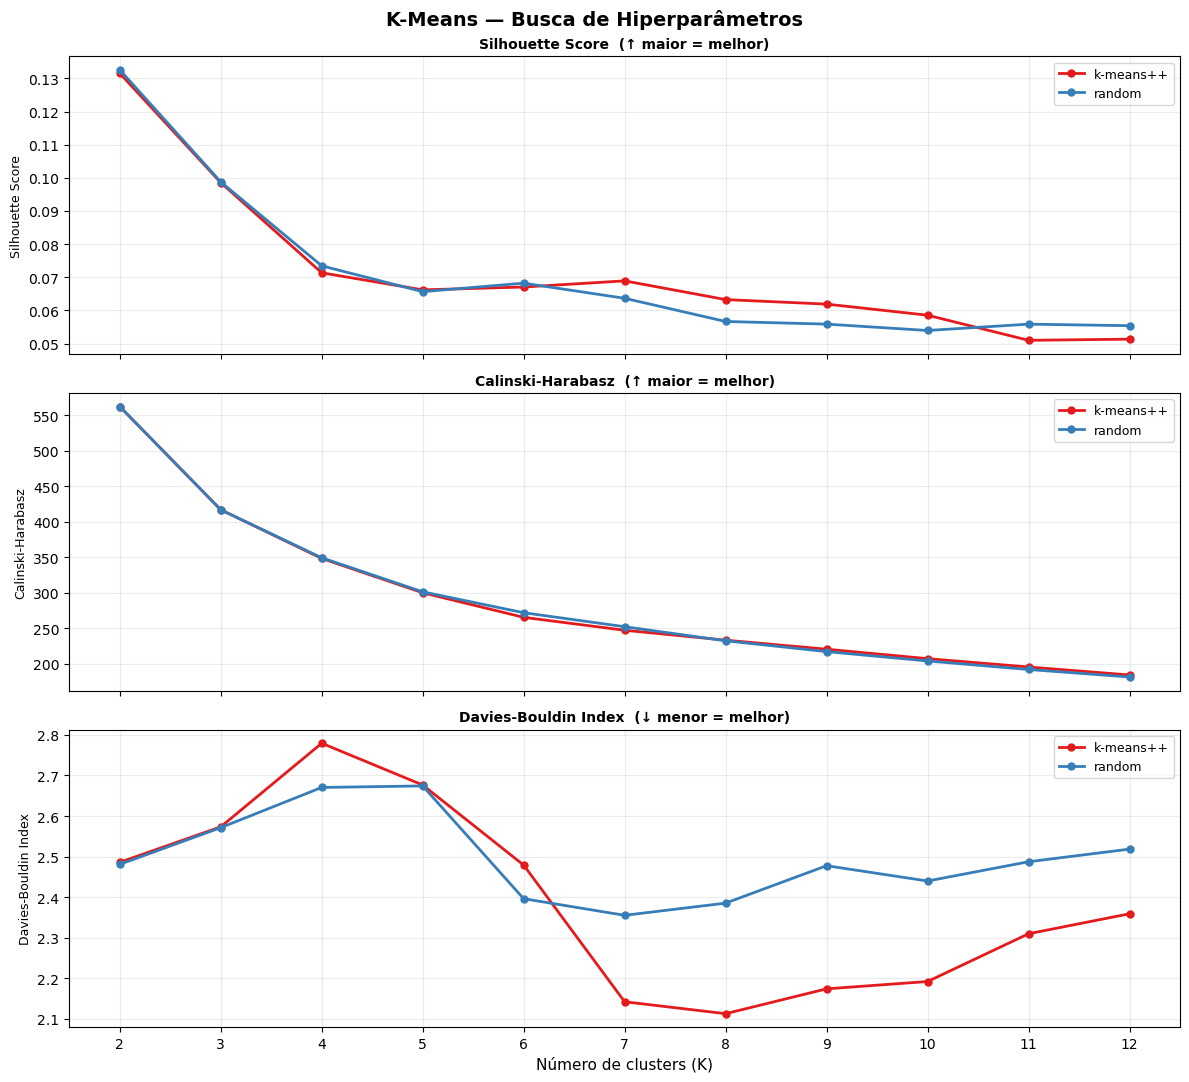

In [20]:
X_scaled_km = StandardScaler().fit_transform(X)

results_km = []
for params in ParameterGrid({'n_clusters': list(range(2, 13)), 'init': ['k-means++', 'random']}):
    km = KMeans(**params, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled_km)
    results_km.append({
        **params,
        'silhouette':     silhouette_score(X_scaled_km, labels),
        'calinski':       calinski_harabasz_score(X_scaled_km, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled_km, labels),
    })

df_km = pd.DataFrame(results_km)
display(df_km.sort_values('davies_bouldin', ascending=False).head(10))

plot_cluster_metrics(df_km, 'n_clusters', 'init',
                     'K-Means — Busca de Hiperparâmetros')

MELHOR CONFIGURAÇÃO POR MÉTRICA — K-Means
  Silhouette  ↑  K= 2, init=random         → 0.1326
  Calinski    ↑  K= 2, init=random         → 562.6
  Davies-B    ↓  K= 8, init=k-means++      → 2.1124

Modelo treinado K_KM2: K=4, init=random
cluster_km2
0    1016
1     835
2    1248
3     791
Name: count, dtype: int64

Modelo treinado K_KM3: K=5, init=random
cluster_km3
0    1062
1     844
2     576
3     674
4     734
Name: count, dtype: int64


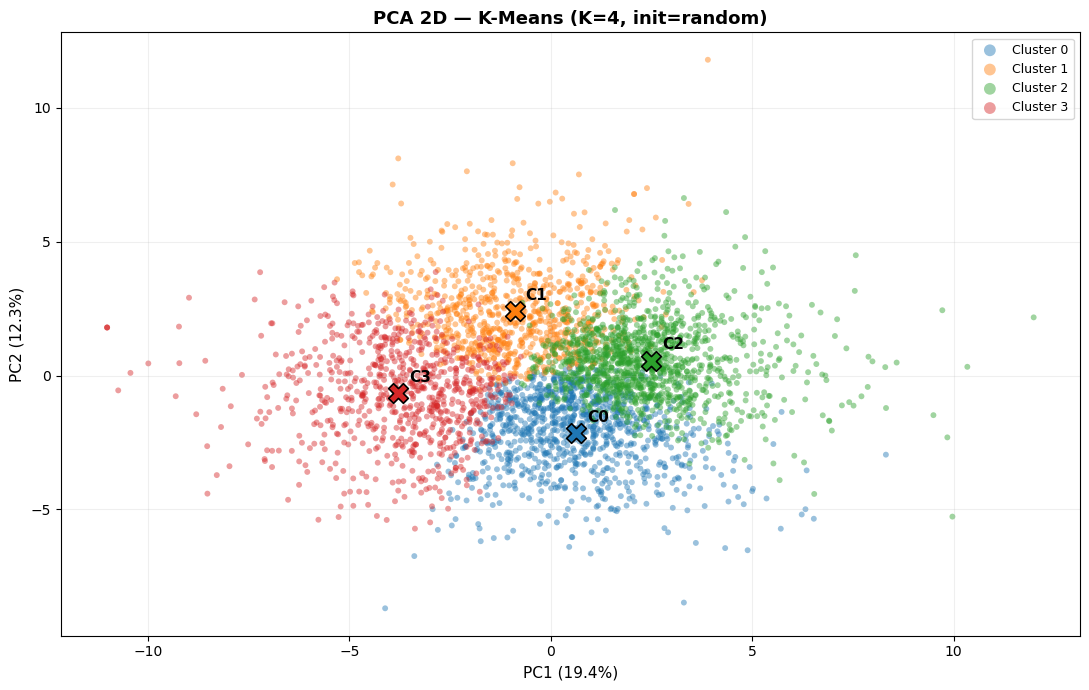

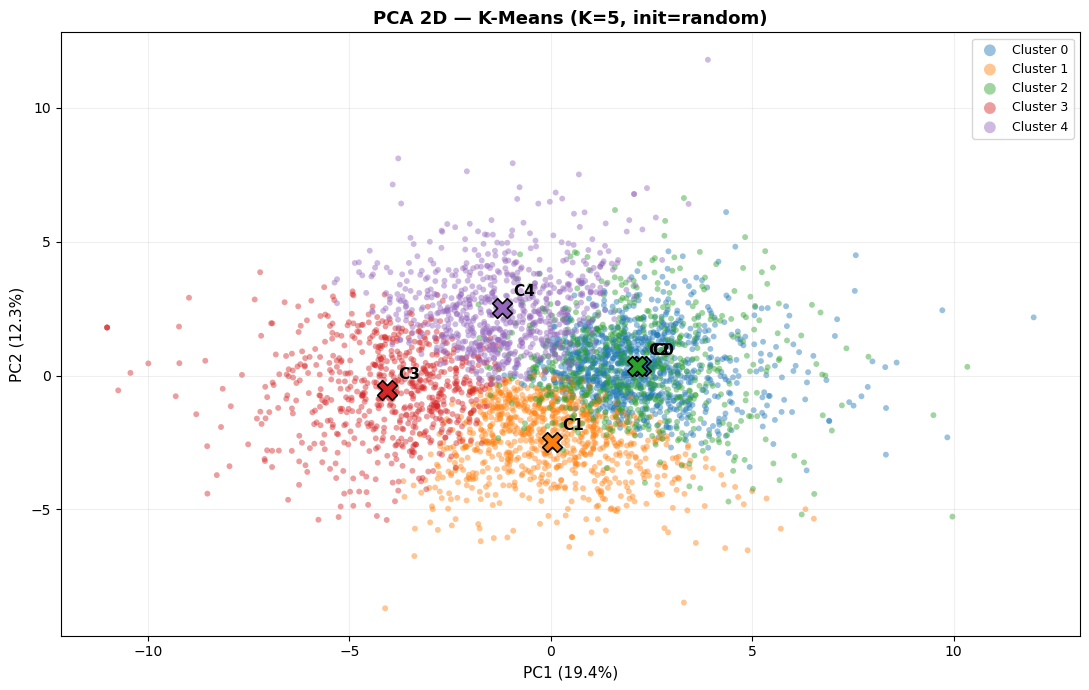

TOP 5 ESTILOS POR CLUSTER — cluster_km2

Cluster 0:


'  Sertanejo                       134'

'  MPB                             125'

'  Pop Rock                        115'

'  Ritmos Variados                 107'

...

'  MPB                             177'

'  Sertanejo                        99'

'  Ritmos Variados                  87'

'  Pop Rock                         70'

'  Pop                              50'

In [21]:
# ── Resumo das melhores configurações ─────────────────────
best_sil_km = df_km.loc[df_km['silhouette'].idxmax()]
best_cal_km = df_km.loc[df_km['calinski'].idxmax()]
best_dbi_km = df_km.loc[df_km['davies_bouldin'].idxmin()]

print("=" * 58)
print("MELHOR CONFIGURAÇÃO POR MÉTRICA — K-Means")
print("=" * 58)
print(f"  Silhouette  ↑  K={int(best_sil_km.n_clusters):>2}, init={best_sil_km.init:<14} → {best_sil_km.silhouette:.4f}")
print(f"  Calinski    ↑  K={int(best_cal_km.n_clusters):>2}, init={best_cal_km.init:<14} → {best_cal_km.calinski:.1f}")
print(f"  Davies-B    ↓  K={int(best_dbi_km.n_clusters):>2}, init={best_dbi_km.init:<14} → {best_dbi_km.davies_bouldin:.4f}")
print("=" * 58)

# ── Treinar modelo final ───────────────────────────────────
# Usando o melhor K e init por Silhouette — ajuste aqui se preferir outro critério
K_KM2   = 4
K_KM3   = 5
INIT_KM = best_sil_km['init']

pipe_km2 = Pipeline([
    ('scaler',  StandardScaler()),
    ('cluster', KMeans(n_clusters=K_KM2, init=INIT_KM, random_state=42, n_init='auto'))
])
labels_km2 = pipe_km2.fit_predict(X)
audios['cluster_km2'] = labels_km2

print(f"\nModelo treinado K_KM2: K={K_KM2}, init={INIT_KM}")
print(audios['cluster_km2'].value_counts().sort_index())

pipe_km3 = Pipeline([
    ('scaler',  StandardScaler()),
    ('cluster', KMeans(n_clusters=K_KM3, init=INIT_KM, random_state=42, n_init='auto'))
])
labels_km3 = pipe_km3.fit_predict(X)
audios['cluster_km3'] = labels_km3

print(f"\nModelo treinado K_KM3: K={K_KM3}, init={INIT_KM}")
print(audios['cluster_km3'].value_counts().sort_index())

# ── Visualização PCA 2D ───────────────────────────────────
X_scaled_km2  = pipe_km2['scaler'].transform(X)
centroids_km2 = pipe_km2['cluster'].cluster_centers_
plot_pca_2d(X_scaled_km2, labels_km2,
            f'PCA 2D — K-Means (K={K_KM2}, init={INIT_KM})',
            centroids=centroids_km2)

centroids_km3 = pipe_km3['cluster'].cluster_centers_
plot_pca_2d(X_scaled_km2, labels_km3,
            f'PCA 2D — K-Means (K={K_KM3}, init={INIT_KM})',
            centroids=centroids_km3)

# ── Top 5 estilos por cluster ─────────────────────────────
print_top_styles(audios, 'cluster_km2')
print_top_styles(audios, 'cluster_km3')

## Passo 1.3 — GMM (Gaussian Mixture Model)

Busca dos melhores hiperparâmetros via `ParameterGrid`:
- `n_components`: 2 a 12
- `covariance_type`: full, tied, diag

> GMM não possui `fit_predict` — usa `fit` + `predict` separados (sem Pipeline).

Avaliação com as mesmas 3 métricas: **Silhouette**, **Calinski-Harabasz**, **Davies-Bouldin**.

,covariance_type,n_components,silhouette,calinski,davies_bouldin
11,tied,2,0.258341,126.646464,1.986313
18,tied,9,0.039209,121.873720,2.189585
17,tied,8,0.029789,106.409701,2.329663
16,tied,7,0.036430,112.749087,2.387793
19,tied,10,0.035709,119.152613,2.489020
21,tied,12,0.028660,108.574183,2.512193
20,tied,11,0.031335,120.926139,2.633806
8,full,10,0.035490,148.056046,2.657311
22,diag,2,0.127362,485.515391,2.702206
15,tied,6,0.033387,115.374690,2.723488


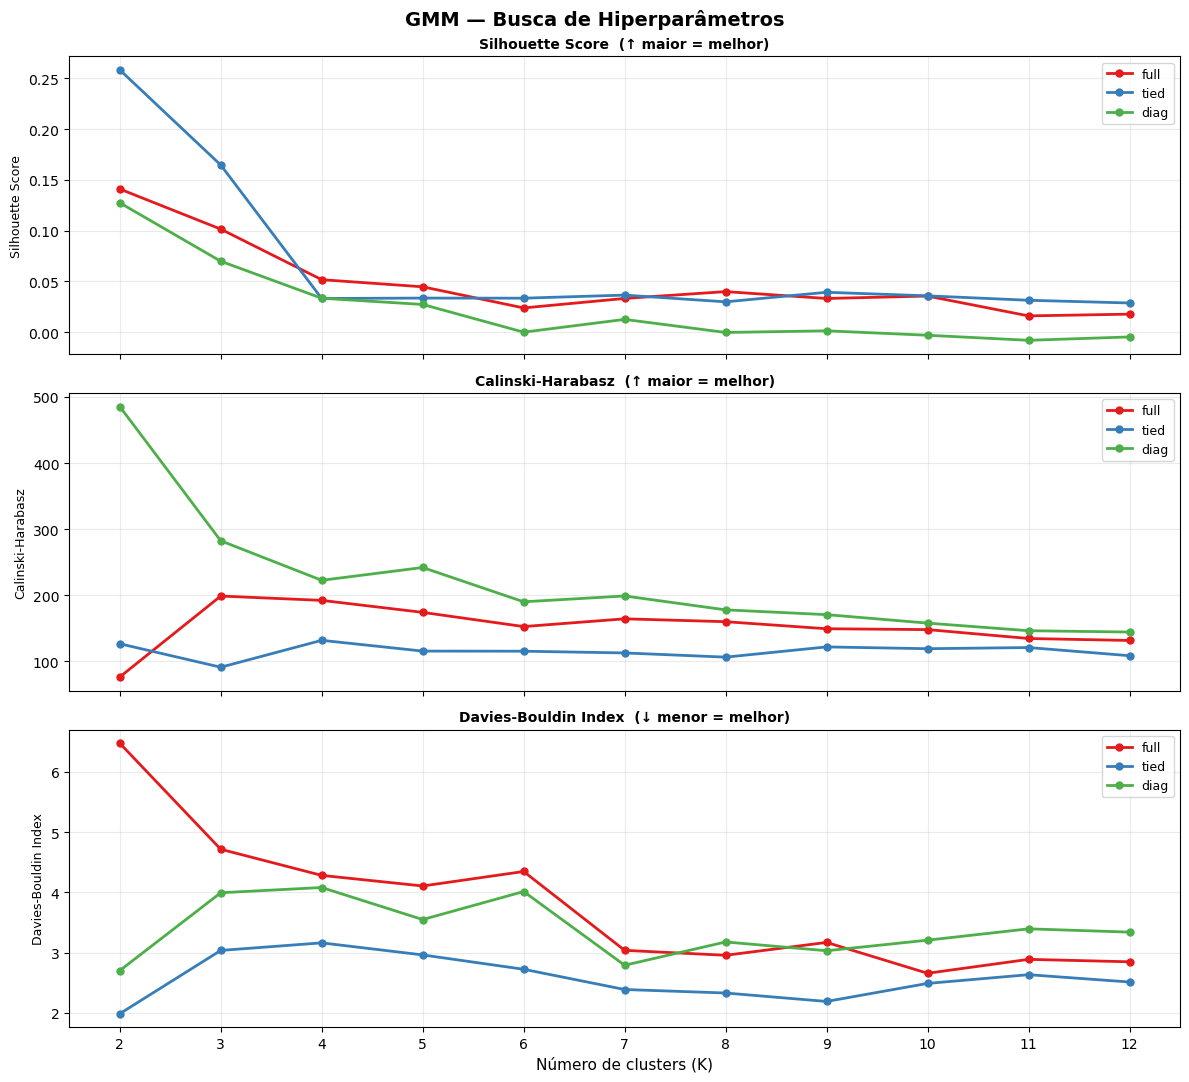

In [22]:
X_scaled_gmm = StandardScaler().fit_transform(X)

results_gmm = []
for params in ParameterGrid({'n_components': list(range(2, 13)), 'covariance_type': ['full', 'tied', 'diag']}):
    gmm = GaussianMixture(**params, random_state=42)
    gmm.fit(X_scaled_gmm)
    labels = gmm.predict(X_scaled_gmm)
    results_gmm.append({
        **params,
        'silhouette':     silhouette_score(X_scaled_gmm, labels),
        'calinski':       calinski_harabasz_score(X_scaled_gmm, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled_gmm, labels),
    })

df_gmm = pd.DataFrame(results_gmm)
display(df_gmm.sort_values('davies_bouldin').head(10))

plot_cluster_metrics(df_gmm, 'n_components', 'covariance_type',
                     'GMM — Busca de Hiperparâmetros')

MELHOR CONFIGURAÇÃO POR MÉTRICA — GMM
  Silhouette  ↑  K= 2, cov=tied     → 0.2583
  Calinski    ↑  K= 2, cov=diag     → 485.5
  Davies-B    ↓  K= 2, cov=tied     → 1.9863

Modelo treinado: K=4, covariance_type=tied
cluster_gmm2
0     168
1     935
2    2688
3      99
Name: count, dtype: int64


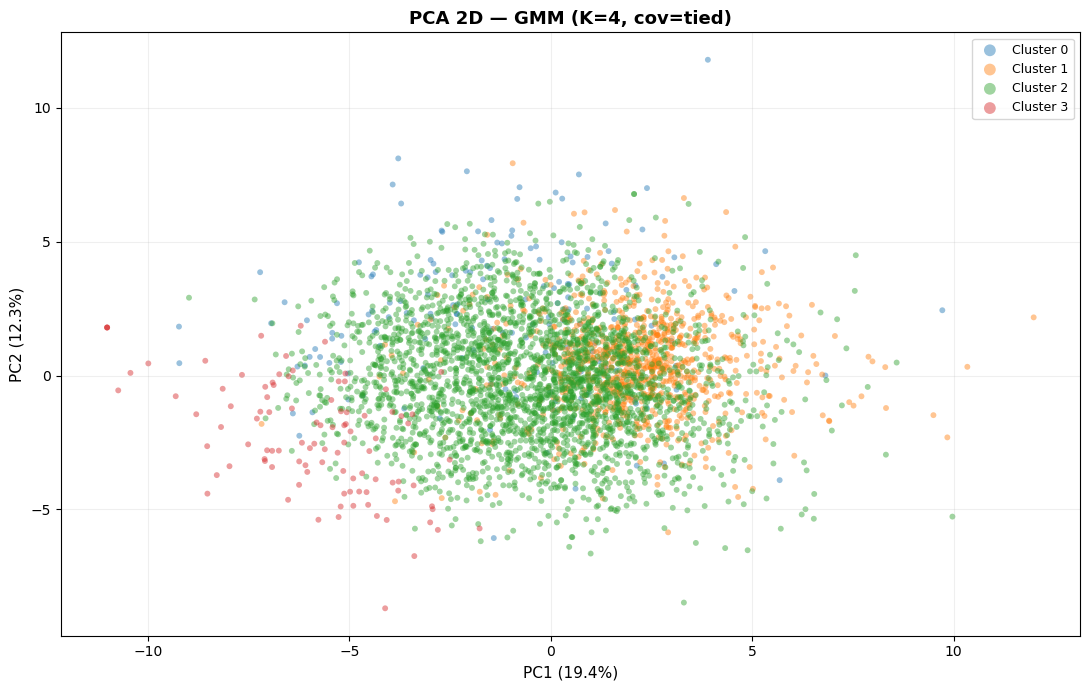

TOP 5 ESTILOS POR CLUSTER — cluster_gmm2

Cluster 0:


'  MPB                              29'

'  Pop Rock                         19'

'  Ritmos Variados                  18'

'  Sertanejo                        13'

...

'  MPB                              24'

'  Jazz                             21'

'  Ritmos Variados                  13'

'  Sertanejo                         6'

'  Músicas Internacionais            5'

In [23]:
# ── Resumo das melhores configurações ─────────────────────
best_sil_gmm = df_gmm.loc[df_gmm['silhouette'].idxmax()]
best_cal_gmm = df_gmm.loc[df_gmm['calinski'].idxmax()]
best_dbi_gmm = df_gmm.loc[df_gmm['davies_bouldin'].idxmin()]

print("=" * 62)
print("MELHOR CONFIGURAÇÃO POR MÉTRICA — GMM")
print("=" * 62)
print(f"  Silhouette  ↑  K={int(best_sil_gmm.n_components):>2}, cov={best_sil_gmm.covariance_type:<8} → {best_sil_gmm.silhouette:.4f}")
print(f"  Calinski    ↑  K={int(best_cal_gmm.n_components):>2}, cov={best_cal_gmm.covariance_type:<8} → {best_cal_gmm.calinski:.1f}")
print(f"  Davies-B    ↓  K={int(best_dbi_gmm.n_components):>2}, cov={best_dbi_gmm.covariance_type:<8} → {best_dbi_gmm.davies_bouldin:.4f}")
print("=" * 62)

# ── Treinar modelo final ───────────────────────────────────
# Ajuste K_GMM2 e COV_GMM conforme sua análise das métricas
K_GMM2   = 4
COV_GMM  = best_dbi_gmm['covariance_type']

scaler_gmm  = StandardScaler()
X_scaled_gmm_final = scaler_gmm.fit_transform(X)

best_gmm = GaussianMixture(n_components=K_GMM2, covariance_type=COV_GMM, random_state=42)
best_gmm.fit(X_scaled_gmm_final)
labels_gmm2 = best_gmm.predict(X_scaled_gmm_final)
audios['cluster_gmm2'] = labels_gmm2

print(f"\nModelo treinado: K={K_GMM2}, covariance_type={COV_GMM}")
print(audios['cluster_gmm2'].value_counts().sort_index())

# ── Visualização PCA 2D ───────────────────────────────────
plot_pca_2d(X_scaled_gmm_final, labels_gmm2,
            f'PCA 2D — GMM (K={K_GMM2}, cov={COV_GMM})')

# ── Top 5 estilos por cluster ─────────────────────────────
print_top_styles(audios, 'cluster_gmm2')

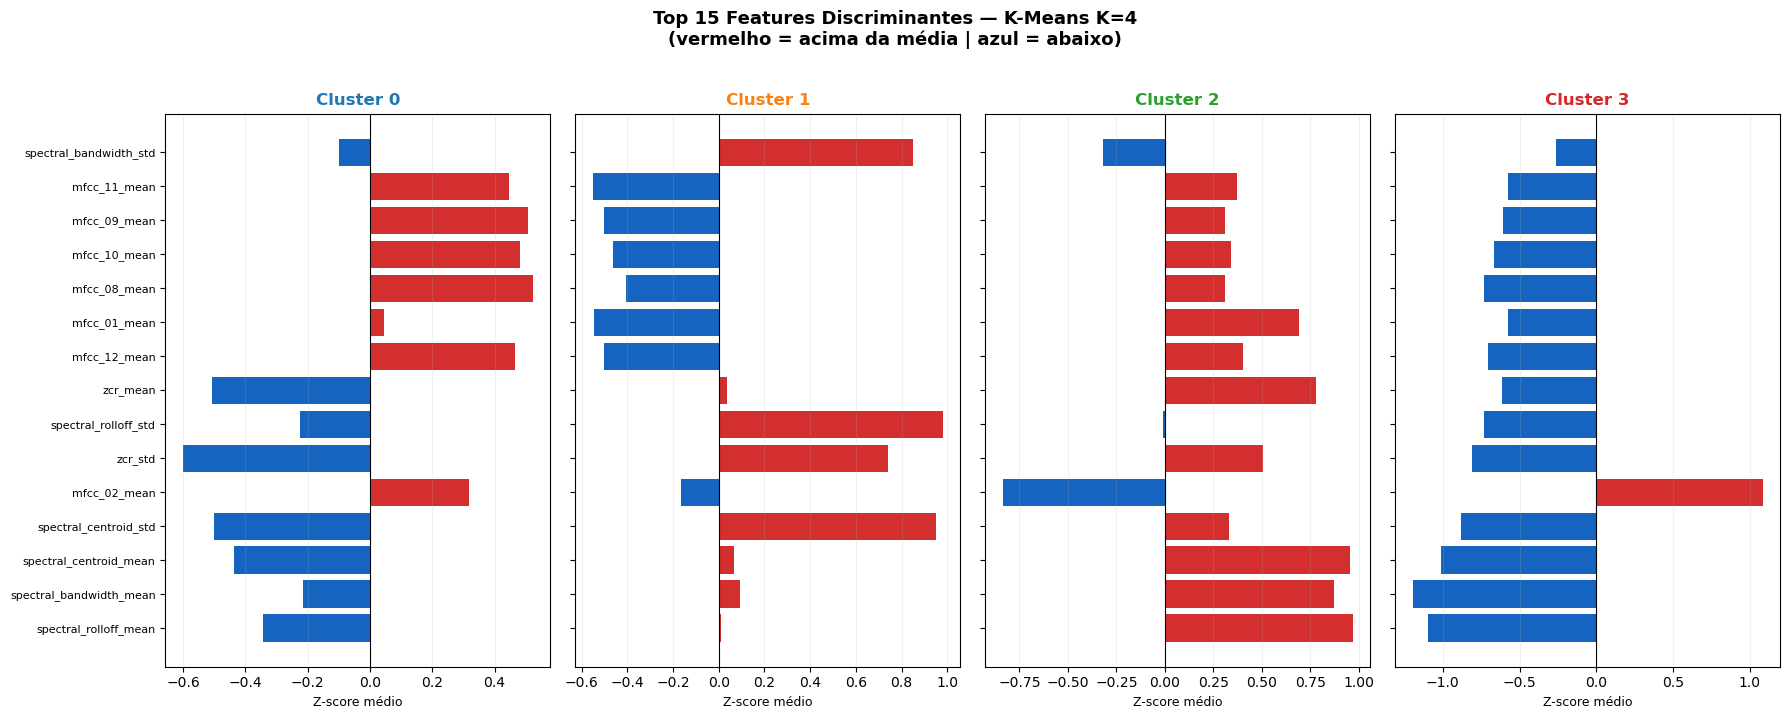

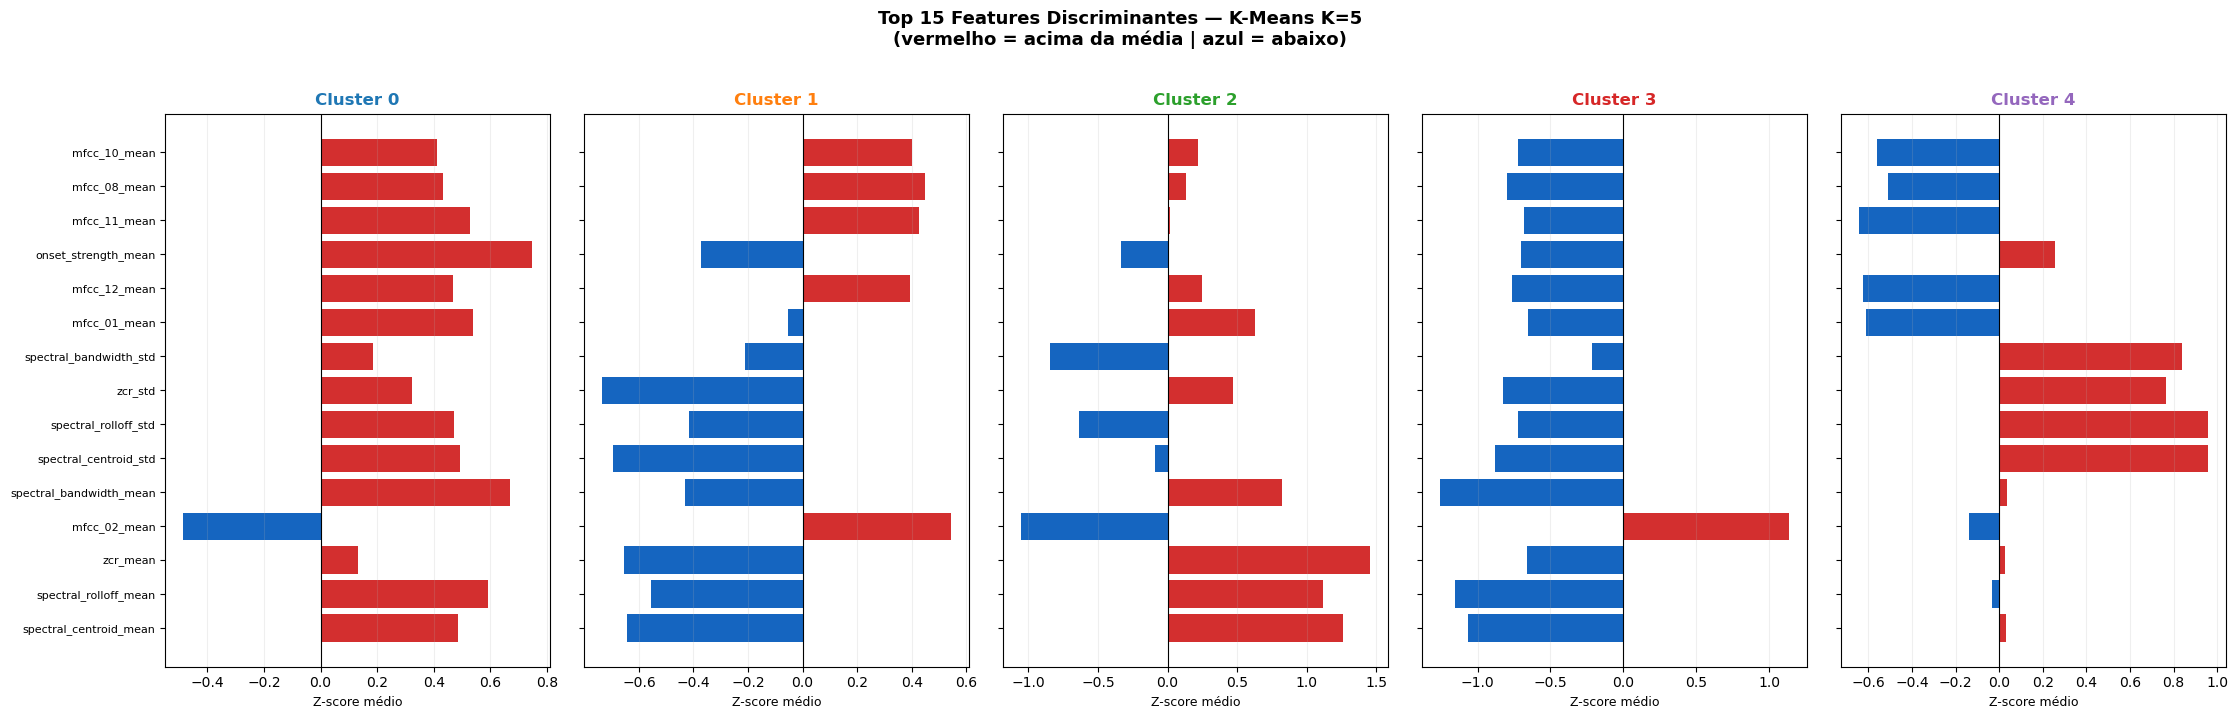

In [24]:
def plot_top_features_by_cluster(X_scaled, labels, title, n_top=15):
    """Barplot horizontal das top N features discriminantes por cluster (z-score médio)."""
    unique_clusters = sorted(np.unique(labels))
    n_clusters = len(unique_clusters)

    df_s = pd.DataFrame(X_scaled, columns=features_audio)
    df_s['cluster'] = labels
    media = df_s.groupby('cluster')[features_audio].mean()

    top_feats = media.var(axis=0).sort_values(ascending=False).head(n_top).index.tolist()
    cluster_colors = [plt.cm.tab10(i / 10) for i in range(n_clusters)]

    fig, axes = plt.subplots(1, n_clusters, figsize=(4.5 * n_clusters, 7), sharey=True)
    if n_clusters == 1:
        axes = [axes]

    for ax, lbl in zip(axes, unique_clusters):
        vals = media.loc[lbl, top_feats]
        bar_colors = ['#d32f2f' if v > 0 else '#1565C0' for v in vals]
        ax.barh(top_feats, vals, color=bar_colors, edgecolor='none')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'Cluster {lbl}', fontsize=12, fontweight='bold',
                     color=cluster_colors[lbl])
        ax.grid(True, alpha=0.2, axis='x')
        ax.tick_params(axis='y', labelsize=8)
        ax.set_xlabel('Z-score médio', fontsize=9)

    fig.suptitle(f'{title}\n(vermelho = acima da média | azul = abaixo)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


X_viz = pipe_km2['scaler'].transform(X)

plot_top_features_by_cluster(X_viz, labels_km2,
                              f'Top 15 Features Discriminantes — K-Means K=4')
plot_top_features_by_cluster(X_viz, labels_km3,
                              f'Top 15 Features Discriminantes — K-Means K=5')

## Passo 3 — Redução de Dimensionalidade (PCA)

Objetivo: reduzir as 40 features de áudio para um espaço menor, eliminando ruído e correlações, e verificar se o K-Means melhora no espaço reduzido.

**Etapas:**
1. Plotar curva de variância cumulativa → escolher `n_components`
2. Aplicar PCA com o número escolhido
3. Re-rodar K-Means no espaço reduzido e comparar métricas com o original

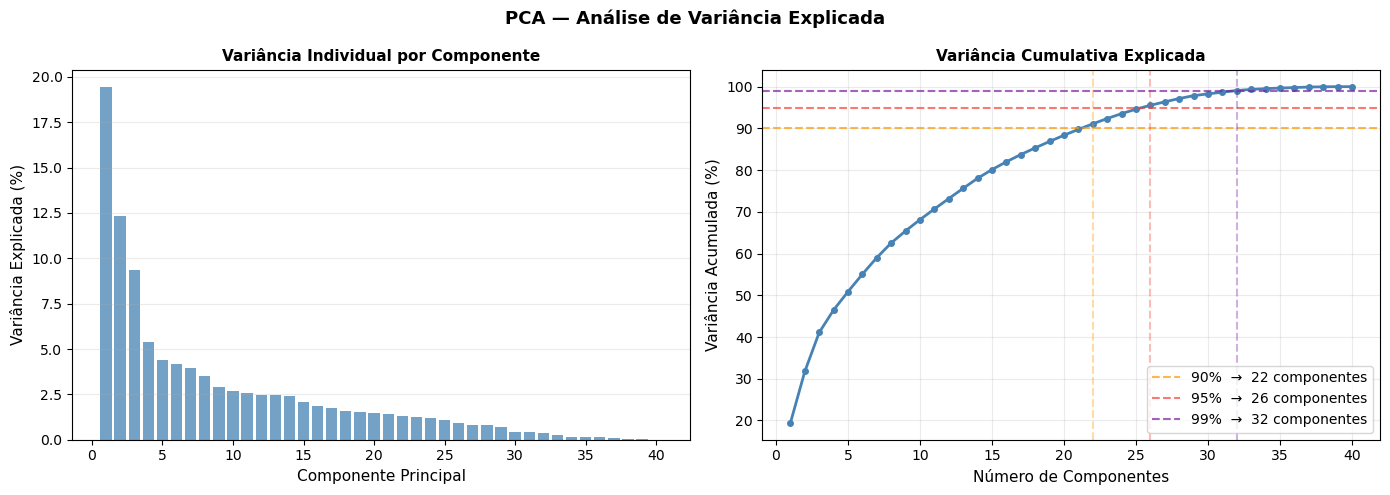

COMPONENTES NECESSÁRIOS POR THRESHOLD
  90% de variância  →  22 componentes
  95% de variância  →  26 componentes
  99% de variância  →  32 componentes
  Total de features originais: 40


In [25]:
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled_pca)

var_ratio  = pca_full.explained_variance_ratio_
var_cumsum = np.cumsum(var_ratio)
n_total    = len(var_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — Análise de Variância Explicada', fontsize=13, fontweight='bold')

# ── Variância por componente ──────────────────────────────
axes[0].bar(range(1, n_total + 1), var_ratio * 100,
            color='steelblue', alpha=0.75, edgecolor='none')
axes[0].set_xlabel('Componente Principal', fontsize=11)
axes[0].set_ylabel('Variância Explicada (%)', fontsize=11)
axes[0].set_title('Variância Individual por Componente', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.25, axis='y')

# ── Variância cumulativa + thresholds ─────────────────────
axes[1].plot(range(1, n_total + 1), var_cumsum * 100,
             'o-', color='steelblue', linewidth=2, markersize=4)
axes[1].set_xlabel('Número de Componentes', fontsize=11)
axes[1].set_ylabel('Variância Acumulada (%)', fontsize=11)
axes[1].set_title('Variância Cumulativa Explicada', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.25)

for threshold, color in [(0.90, '#FF9800'), (0.95, '#F44336'), (0.99, '#7B1FA2')]:
    n_comp = int(np.searchsorted(var_cumsum, threshold)) + 1
    axes[1].axhline(threshold * 100, color=color, linestyle='--', alpha=0.7,
                    label=f'{int(threshold * 100)}%  →  {n_comp} componentes')
    axes[1].axvline(n_comp, color=color, linestyle='--', alpha=0.35)

axes[1].legend(fontsize=10)
plt.tight_layout()
plt.show()

print("=" * 45)
print("COMPONENTES NECESSÁRIOS POR THRESHOLD")
print("=" * 45)
for threshold in [0.90, 0.95, 0.99]:
    n_comp = int(np.searchsorted(var_cumsum, threshold)) + 1
    print(f"  {int(threshold * 100)}% de variância  →  {n_comp} componentes")
print(f"  Total de features originais: {n_total}")
print("=" * 45)

### Passo 3.2 — K-Means K=4 no Espaço Reduzido (PCA 26 componentes)

Aplicar PCA com 26 componentes (95% da variância) e re-rodar K-Means K=4.
Comparar as 3 métricas com o modelo original para avaliar se a redução melhorou a separação dos clusters.

Shape original:             (3890, 40)
Shape reduzido:             (3890, 26)
Variância total explicada:  95.5%

Distribuição dos clusters (K-Means PCA K=4):
cluster_km_pca
0    1001
1     805
2     829
3    1255
Name: count, dtype: int64

COMPARAÇÃO — K-Means K=4: Original vs PCA (26 comp.)
  Métrica                  Original        PCA            
------------------------------------------------------------
  Silhouette  ↑              0.0734     0.0779  melhorou
  Calinski    ↑            349.3122   369.8823  melhorou
  Davies-B    ↓              2.6705     2.6136  melhorou


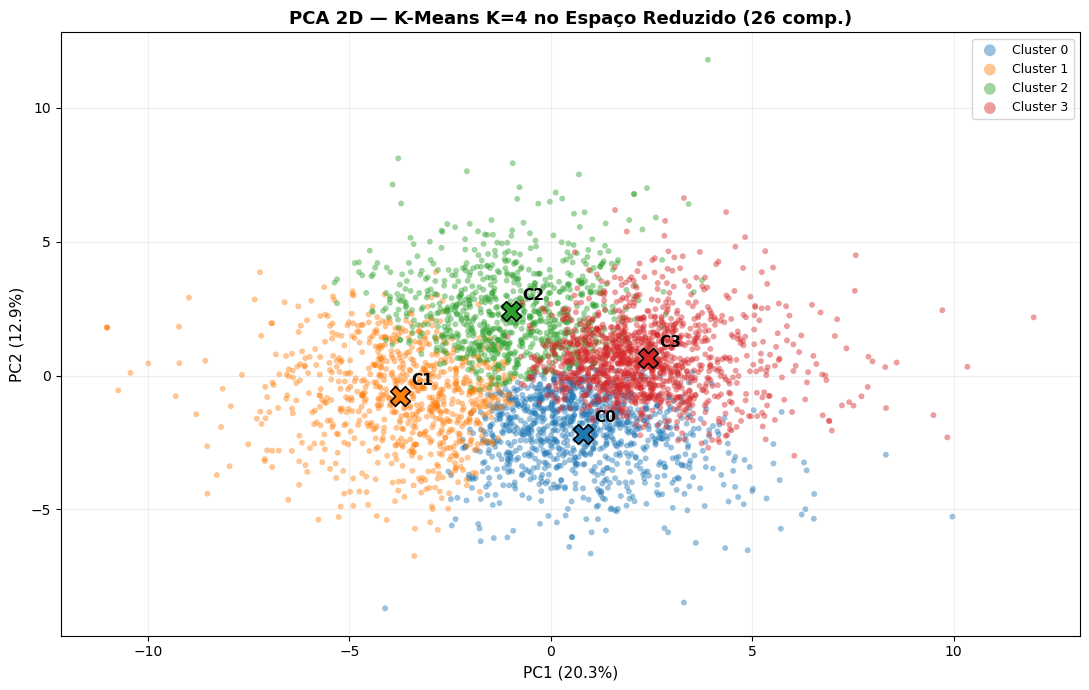

TOP 5 ESTILOS POR CLUSTER — cluster_km_pca

Cluster 0:


'  Sertanejo                       126'

'  MPB                             122'

'  Pop Rock                        118'

'  Ritmos Variados                 105'

...

'  Sertanejo                       327'

'  Pagode                          165'

'  Ritmos Variados                 105'

'  Pop Rock                         86'

'  Samba                            76'

In [26]:
N_COMPONENTS_PCA = 26

# ── Aplicar PCA ───────────────────────────────────────────
pca_26 = PCA(n_components=N_COMPONENTS_PCA, random_state=42)
X_pca_26 = pca_26.fit_transform(X_scaled_pca)

print(f"Shape original:             {X_scaled_pca.shape}")
print(f"Shape reduzido:             {X_pca_26.shape}")
print(f"Variância total explicada:  {pca_26.explained_variance_ratio_.sum()*100:.1f}%")

# ── K-Means no espaço reduzido ────────────────────────────
K_PCA = 4

km_pca = KMeans(n_clusters=K_PCA, init=INIT_KM, random_state=42, n_init='auto')
labels_km_pca = km_pca.fit_predict(X_pca_26)
audios['cluster_km_pca'] = labels_km_pca

print(f"\nDistribuição dos clusters (K-Means PCA K={K_PCA}):")
print(audios['cluster_km_pca'].value_counts().sort_index())

# ── Comparação de métricas: original vs PCA ───────────────
m_orig = {
    'silhouette':     silhouette_score(X_scaled_km, labels_km2),
    'calinski':       calinski_harabasz_score(X_scaled_km, labels_km2),
    'davies_bouldin': davies_bouldin_score(X_scaled_km, labels_km2),
}
m_pca = {
    'silhouette':     silhouette_score(X_pca_26, labels_km_pca),
    'calinski':       calinski_harabasz_score(X_pca_26, labels_km_pca),
    'davies_bouldin': davies_bouldin_score(X_pca_26, labels_km_pca),
}

print("\n" + "=" * 60)
print("COMPARAÇÃO — K-Means K=4: Original vs PCA (26 comp.)")
print("=" * 60)
print(f"  {'Métrica':<22} {'Original':>10} {'PCA':>10}  {'':>10}")
print("-" * 60)
for metric, label, direction in [
    ('silhouette',     'Silhouette  ↑', 'higher'),
    ('calinski',       'Calinski    ↑', 'higher'),
    ('davies_bouldin', 'Davies-B    ↓', 'lower'),
]:
    orig, pca_v = m_orig[metric], m_pca[metric]
    delta = pca_v - orig
    better = (delta > 0 and direction == 'higher') or (delta < 0 and direction == 'lower')
    tag = 'melhorou' if better else 'piorou'
    print(f"  {label:<22} {orig:>10.4f} {pca_v:>10.4f}  {tag}")
print("=" * 60)

# ── Visualização PCA 2D ───────────────────────────────────
plot_pca_2d(X_pca_26, labels_km_pca,
            f'PCA 2D — K-Means K={K_PCA} no Espaço Reduzido (26 comp.)',
            centroids=km_pca.cluster_centers_)

# ── Top 5 estilos por cluster ─────────────────────────────
print_top_styles(audios, 'cluster_km_pca')

### Passo 3.3 — K-Means K=5 no Espaço Reduzido (PCA 26 componentes)

Mesmo processo do K=4, agora com K=5 para comparação completa.

Distribuição dos clusters (K-Means PCA K=5):
cluster_km_pca5
0    1067
1     566
2     734
3     852
4     671
Name: count, dtype: int64

COMPARAÇÃO — K-Means K=5: Original vs PCA (26 comp.)
  Métrica                  Original        PCA            
------------------------------------------------------------
  Silhouette  ↑              0.0657     0.0706  melhorou
  Calinski    ↑            301.2919   319.3682  melhorou
  Davies-B    ↓              2.6742     2.5830  melhorou


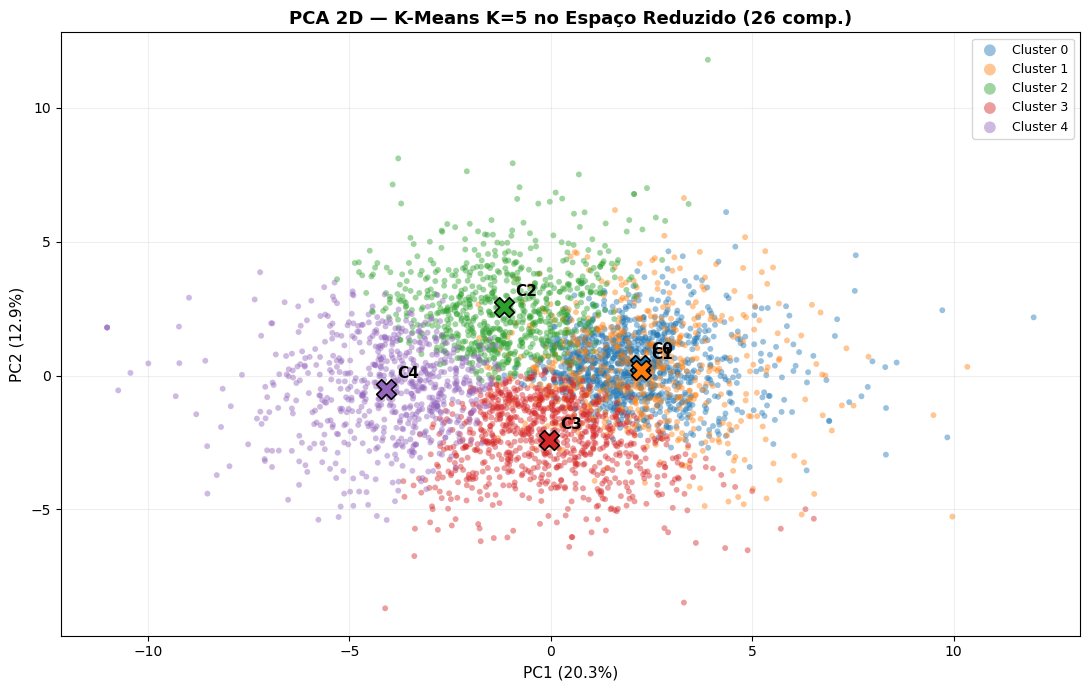

TOP 5 ESTILOS POR CLUSTER — cluster_km_pca5

Cluster 0:


'  Sertanejo                       305'

'  Pagode                          146'

'  MPB                              86'

'  Ritmos Variados                  83'

...

'  MPB                             159'

'  Ritmos Variados                  98'

'  Sertanejo                        57'

'  Pop Rock                         57'

'  Pop                              44'

In [27]:
K_PCA5 = 5

km_pca5 = KMeans(n_clusters=K_PCA5, init=INIT_KM, random_state=42, n_init='auto')
labels_km_pca5 = km_pca5.fit_predict(X_pca_26)
audios['cluster_km_pca5'] = labels_km_pca5

print(f"Distribuição dos clusters (K-Means PCA K={K_PCA5}):")
print(audios['cluster_km_pca5'].value_counts().sort_index())

m_orig5 = {
    'silhouette':     silhouette_score(X_scaled_km, labels_km3),
    'calinski':       calinski_harabasz_score(X_scaled_km, labels_km3),
    'davies_bouldin': davies_bouldin_score(X_scaled_km, labels_km3),
}
m_pca5 = {
    'silhouette':     silhouette_score(X_pca_26, labels_km_pca5),
    'calinski':       calinski_harabasz_score(X_pca_26, labels_km_pca5),
    'davies_bouldin': davies_bouldin_score(X_pca_26, labels_km_pca5),
}

print("\n" + "=" * 60)
print("COMPARAÇÃO — K-Means K=5: Original vs PCA (26 comp.)")
print("=" * 60)
print(f"  {'Métrica':<22} {'Original':>10} {'PCA':>10}  {'':>10}")
print("-" * 60)
for metric, label, direction in [
    ('silhouette',     'Silhouette  ↑', 'higher'),
    ('calinski',       'Calinski    ↑', 'higher'),
    ('davies_bouldin', 'Davies-B    ↓', 'lower'),
]:
    orig, pca_v = m_orig5[metric], m_pca5[metric]
    delta = pca_v - orig
    better = (delta > 0 and direction == 'higher') or (delta < 0 and direction == 'lower')
    tag = 'melhorou' if better else 'piorou'
    print(f"  {label:<22} {orig:>10.4f} {pca_v:>10.4f}  {tag}")
print("=" * 60)

plot_pca_2d(X_pca_26, labels_km_pca5,
            f'PCA 2D — K-Means K={K_PCA5} no Espaço Reduzido (26 comp.)',
            centroids=km_pca5.cluster_centers_)

print_top_styles(audios, 'cluster_km_pca5')

In [28]:
comparison = {
    'KM K=4 original': {
        'Silhouette ↑':     silhouette_score(X_scaled_km, labels_km2),
        'Calinski ↑':       calinski_harabasz_score(X_scaled_km, labels_km2),
        'Davies-Bouldin ↓': davies_bouldin_score(X_scaled_km, labels_km2),
    },
    'KM K=5 original': {
        'Silhouette ↑':     silhouette_score(X_scaled_km, labels_km3),
        'Calinski ↑':       calinski_harabasz_score(X_scaled_km, labels_km3),
        'Davies-Bouldin ↓': davies_bouldin_score(X_scaled_km, labels_km3),
    },
    'KM K=4 + PCA': {
        'Silhouette ↑':     silhouette_score(X_pca_26, labels_km_pca),
        'Calinski ↑':       calinski_harabasz_score(X_pca_26, labels_km_pca),
        'Davies-Bouldin ↓': davies_bouldin_score(X_pca_26, labels_km_pca),
    },
    'KM K=5 + PCA': {
        'Silhouette ↑':     silhouette_score(X_pca_26, labels_km_pca5),
        'Calinski ↑':       calinski_harabasz_score(X_pca_26, labels_km_pca5),
        'Davies-Bouldin ↓': davies_bouldin_score(X_pca_26, labels_km_pca5),
    },
}

df_comp = pd.DataFrame(comparison).T

def highlight_best(s, direction='higher'):
    best = s.max() if direction == 'higher' else s.min()
    return ['background-color: #c8e6c9; font-weight: bold' if v == best else '' for v in s]

styled = (df_comp.style
    .apply(highlight_best, direction='higher', subset=['Silhouette ↑'])
    .apply(highlight_best, direction='higher', subset=['Calinski ↑'])
    .apply(highlight_best, direction='lower',  subset=['Davies-Bouldin ↓'])
    .format('{:.4f}')
    .set_caption('Comparação de Modelos — verde = melhor resultado por métrica')
)
display(styled)

,Silhouette ↑,Calinski ↑,Davies-Bouldin ↓
KM K=4 original,0.0734,349.3122,2.6705
KM K=5 original,0.0657,301.2919,2.6742
KM K=4 + PCA,0.0779,369.8823,2.6136
KM K=5 + PCA,0.0706,319.3682,2.5830


### Conclusao

O modelo K-means foi oque desenvolveu melhor e aplicando o PCA teve uma melhora. 

**modelo**: K-Means
**k = 4**


## Passo 4 — DBSCAN: Análise de Outliers

Aplicamos DBSCAN no espaço **PCA-26** (mesmo do K-Means vencedor com K=4) para identificar bandas/áudios **atípicos** (label = -1 = ruído).

**Passo 4.1 — Escolha de `eps` via k-distance plot:**
- Para cada ponto, calcula a distância ao k-ésimo vizinho mais próximo
- Ordena as distâncias em ordem crescente
- O "cotovelo" do gráfico indica um bom valor de `eps`
- Plotamos com `k=2` e `k=5` lado a lado para comparar

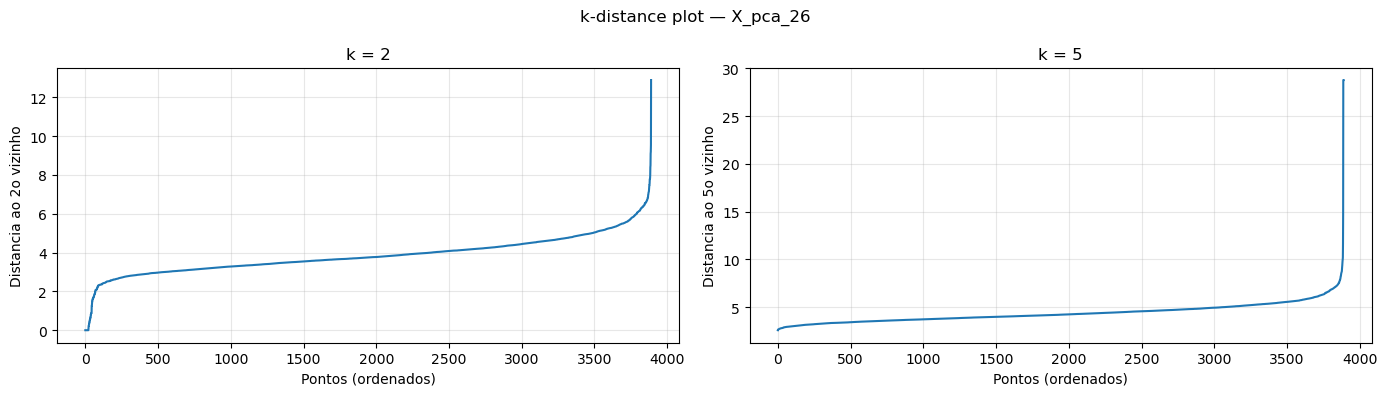

In [29]:
from sklearn.neighbors import NearestNeighbors

def plot_k_distance(X, k_values=(2, 5), title='k-distance plot'):
    """Plota a distância ao k-ésimo vizinho mais próximo ordenada — ajuda a escolher eps do DBSCAN."""
    fig, axes = plt.subplots(1, len(k_values), figsize=(7*len(k_values), 4))
    if len(k_values) == 1:
        axes = [axes]
    for ax, k in zip(axes, k_values):
        nn = NearestNeighbors(n_neighbors=k).fit(X)
        dists, _ = nn.kneighbors(X)
        k_dist = np.sort(dists[:, k-1])
        ax.plot(k_dist)
        ax.set_xlabel('Pontos (ordenados)')
        ax.set_ylabel(f'Distancia ao {k}o vizinho')
        ax.set_title(f'k = {k}')
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_k_distance(X_pca_26, k_values=(2, 5), title='k-distance plot — X_pca_26')

### Passo 4.2 — Treinar DBSCAN e visualizar

`DBSCAN(eps=5.5, min_samples=2)` no `X_pca_26`. Reportamos nº de clusters densos, % de ruído, e visualizamos em PCA 2D com outliers em preto.

DBSCAN(eps=5.5, min_samples=2)
Clusters densos encontrados: 6
Pontos ruido (-1): 192 (4.94%)

Tamanho de cada cluster (top 10):
 0    3686
-1     192
 3       3
 4       3
 1       2
 2       2
 5       2
Name: count, dtype: int64


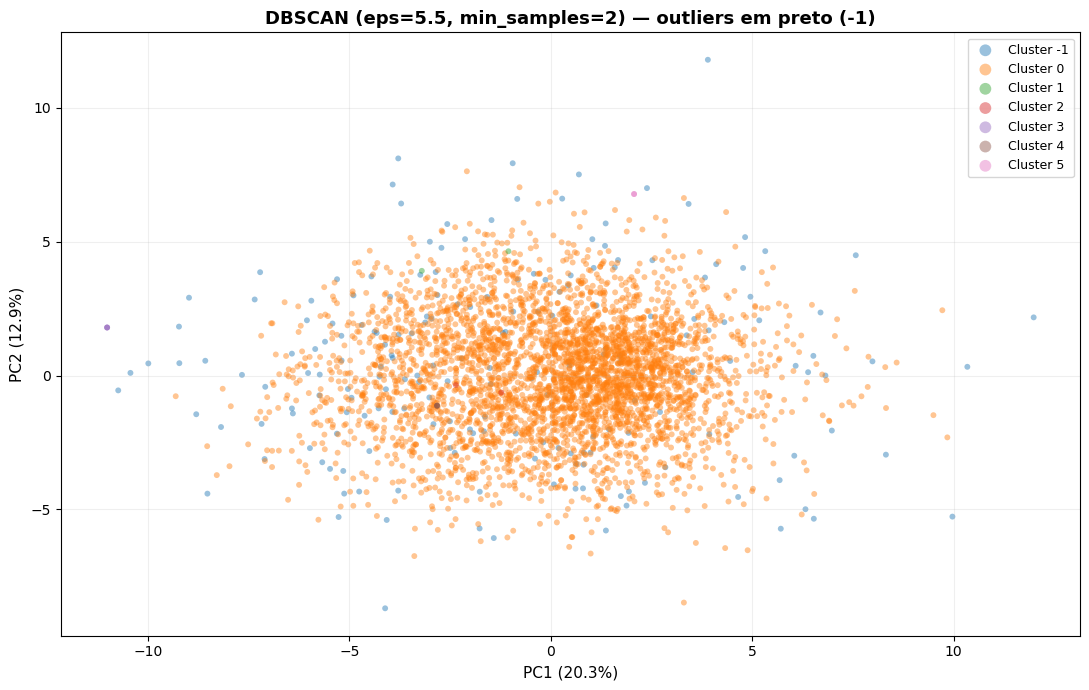

In [30]:
from sklearn.cluster import DBSCAN

EPS_DBSCAN = 5.5
MIN_SAMPLES_DBSCAN = 2

dbscan = DBSCAN(eps=EPS_DBSCAN, min_samples=MIN_SAMPLES_DBSCAN)
labels_dbscan = dbscan.fit_predict(X_pca_26)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = (labels_dbscan == -1).sum()
pct_noise = 100 * n_noise / len(labels_dbscan)

print(f'DBSCAN(eps={EPS_DBSCAN}, min_samples={MIN_SAMPLES_DBSCAN})')
print(f'Clusters densos encontrados: {n_clusters}')
print(f'Pontos ruido (-1): {n_noise} ({pct_noise:.2f}%)')
print()
print('Tamanho de cada cluster (top 10):')
print(pd.Series(labels_dbscan).value_counts().head(10))

# Visualizacao PCA 2D - reusa funcao
plot_pca_2d(X_pca_26, labels_dbscan, title=f'DBSCAN (eps={EPS_DBSCAN}, min_samples={MIN_SAMPLES_DBSCAN}) — outliers em preto (-1)')

#### Conclusão técnica — DBSCAN

O DBSCAN identificou **1 cluster denso dominante** (3686 pontos, 95%) e **192 outliers** (~5%), com 5 micro-agrupamentos residuais (2-3 pontos cada) que devem ser tratados como ruído junto ao label `-1`.

**Interpretação:**
- O espaço **PCA-26 é densamente coeso** — não há subestruturas densas separáveis pelo critério de densidade. Isso é coerente com o K-Means K=4 ter sido o melhor: os 4 grupos são divisões de um espaço contínuo, não ilhas de densidade.
- A taxa de ruído de **~5% cai na faixa ideal** (5-15%) para análise de anomalias, indicando que `eps=5.5` está bem calibrado para o cotovelo do k-distance plot.
- Os outliers são **estatisticamente significativos e investigáveis** — número pequeno o bastante para perfilar manualmente, grande o bastante para revelar padrões.

**Implicação para o pipeline:** o DBSCAN **não substitui o K-Means**, mas o **complementa** sinalizando quais pontos exigem inspeção qualitativa (gêneros raros, áudios com qualidade atípica, ou perfis sonoros únicos). Próxima etapa: cruzar `labels_dbscan` com `labels_km_pca` (K=4) para identificar em qual cluster os outliers se concentram e perfilar suas features distintivas.

### Passo 4.3 — Cross-tab DBSCAN × K-Means K=4

Consolidamos todos os pontos com label ≠ 0 do DBSCAN como **"outlier"** (inclui `-1` e os micro-clusters 1-5). Cruzamos com `labels_km2` (K-Means K=4 no espaço original) para identificar em qual cluster os outliers se concentram.

In [31]:
# Consolida -1 e micro-clusters (1-5) como 'outlier', cluster 0 do DBSCAN como 'denso'
outlier_mask = labels_dbscan != 0
outlier_label = np.where(outlier_mask, 'outlier', 'denso')

# Cross-tab DBSCAN (binarizado) x K-Means K=4
crosstab = pd.crosstab(
    pd.Series(labels_km2, name='K-Means K=4'),
    pd.Series(outlier_label, name='DBSCAN'),
    margins=True,
    margins_name='Total'
)

# % de outliers dentro de cada cluster do K-Means
crosstab['% outlier'] = (crosstab['outlier'] / crosstab['Total'] * 100).round(2)

print('Cross-tab K-Means K=4 x DBSCAN (outlier vs denso):')
display(crosstab)

print(f"Total de outliers consolidados: {outlier_mask.sum()} ({100*outlier_mask.mean():.2f}%)")

Cross-tab K-Means K=4 x DBSCAN (outlier vs denso):


DBSCAN,denso,outlier,Total,% outlier
K-Means K=4,,,,
0,977,39,1016,3.84
1,791,44,835,5.27
2,1211,37,1248,2.96
3,707,84,791,10.62
Total,3686,204,3890,5.24


Total de outliers consolidados: 204 (5.24%)


### Passo 4.4 — Perfil das features dos outliers

Comparamos as features que mais discriminam os outliers do grupo denso, usando `plot_top_features_by_cluster` no `X_scaled_km` com o label binário (denso vs outlier).

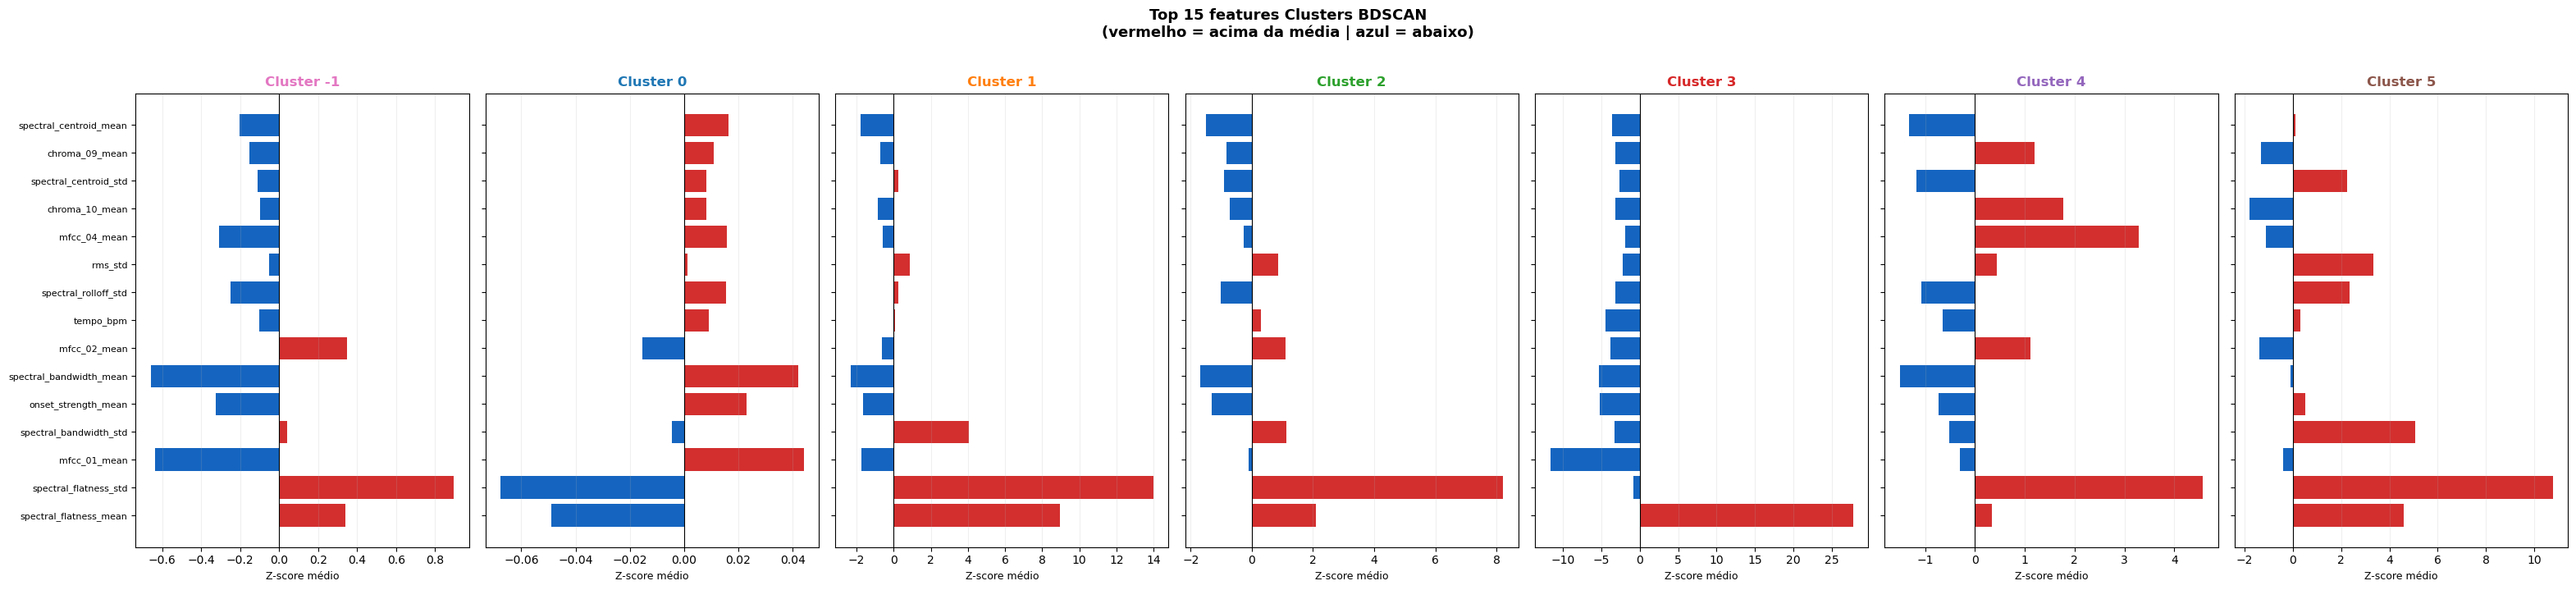

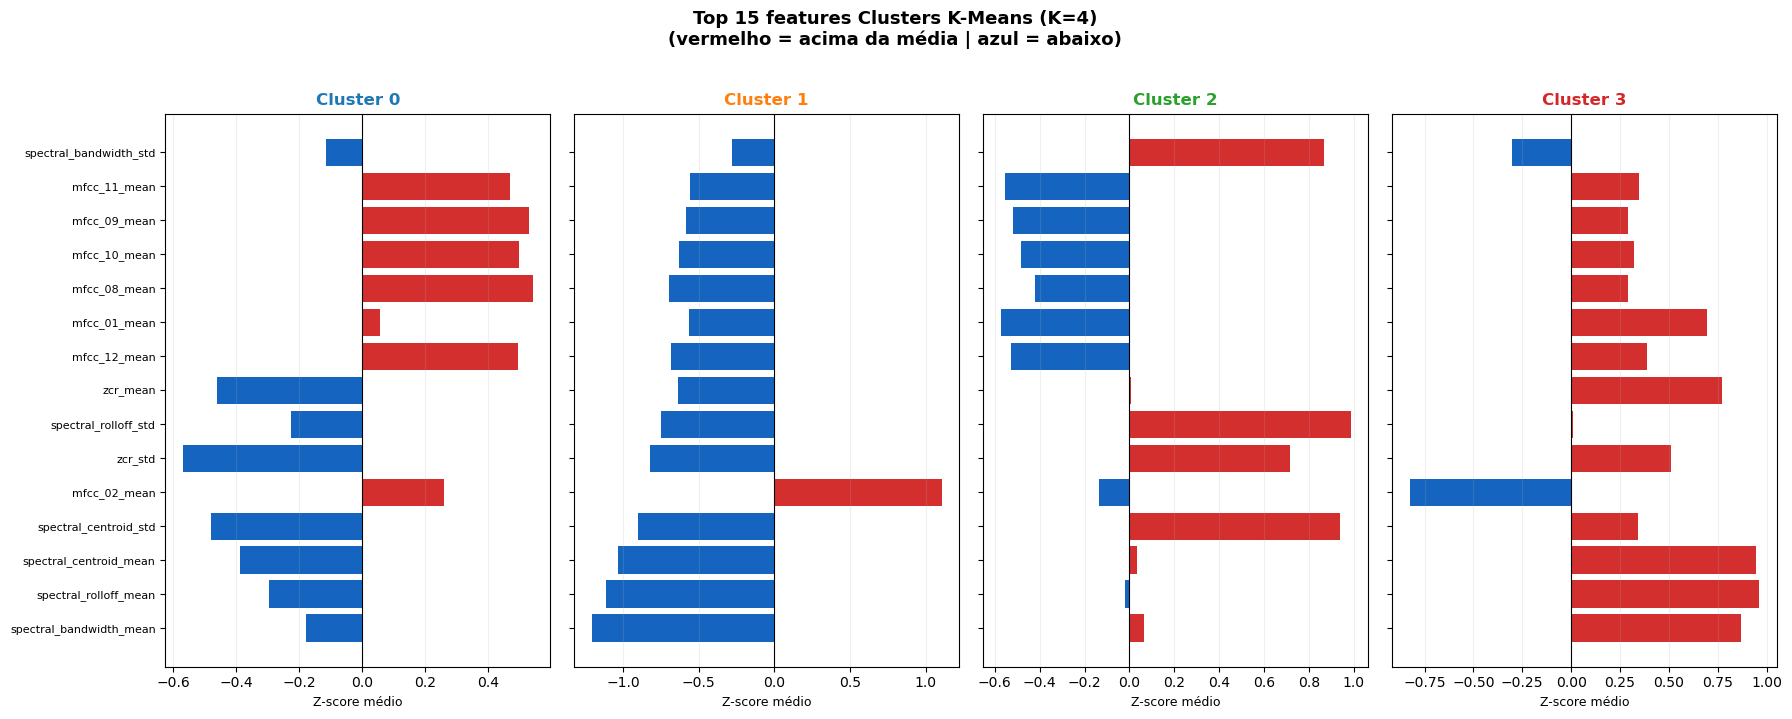

In [32]:
# Reusa funcao - aplica labels binarios (denso/outlier) sobre as features escaladas
plot_top_features_by_cluster(
    X_scaled_km,
    labels_dbscan,
    title='Top 15 features Clusters BDSCAN',
    n_top=15
)
plot_top_features_by_cluster(
    X_scaled_km,
    labels_km_pca,
    title='Top 15 features Clusters K-Means (K=4)',
    n_top=15
)

## Passo 5 — Nomeando os Clusters (K-Means K=4)

Calculamos a **média de cada feature por cluster** (em z-score, sobre `X_scaled_km` (espaço original) agrupados pelos labels do K-Means K=4 treinado no PCA-26 (`labels_km_pca`)) e exibimos como **heatmap** para identificar visualmente o perfil sonoro de cada grupo. Em seguida, atribuímos nomes descritivos baseados nas features dominantes.

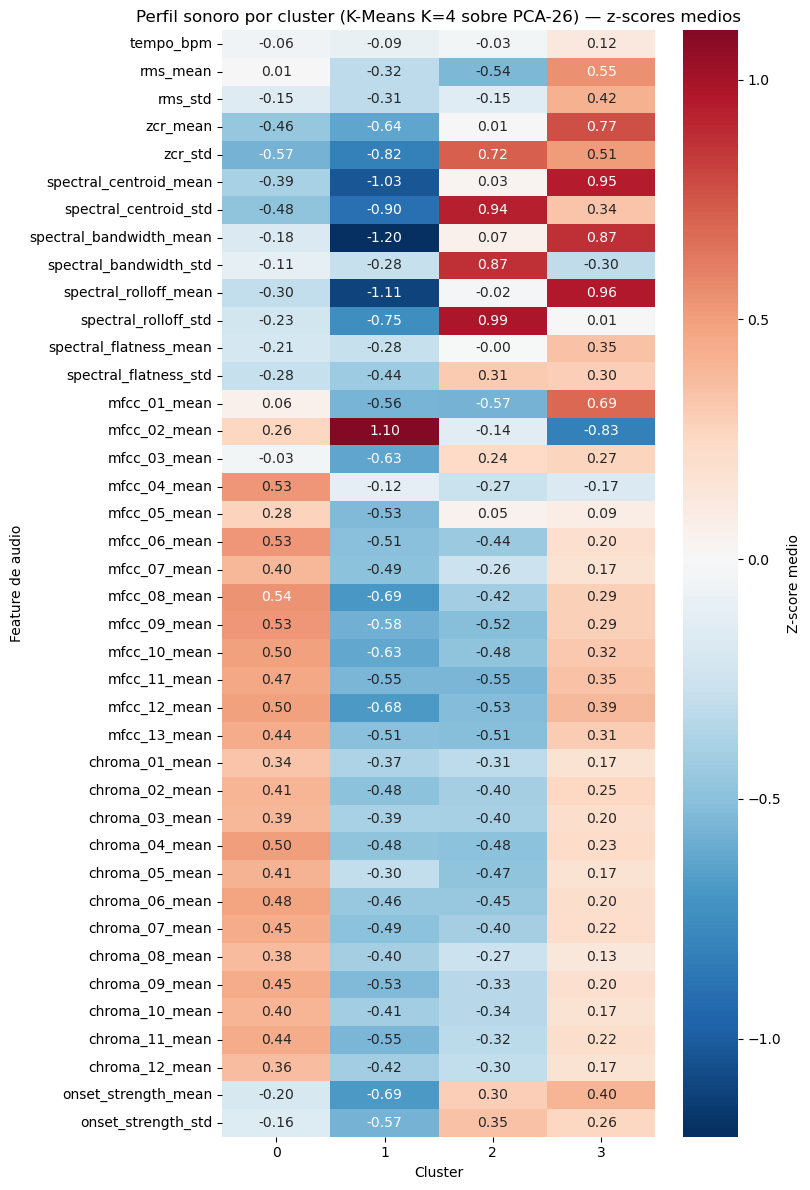

Top 5 features mais ALTAS e mais BAIXAS por cluster:
=== Cluster 0 ===
  Altas:  ['mfcc_08_mean', 'mfcc_04_mean', 'mfcc_09_mean', 'mfcc_06_mean', 'chroma_04_mean']
  Baixas: ['zcr_std', 'spectral_centroid_std', 'zcr_mean', 'spectral_centroid_mean', 'spectral_rolloff_mean']
=== Cluster 1 ===
  Altas:  ['mfcc_02_mean', 'tempo_bpm', 'mfcc_04_mean', 'spectral_flatness_mean', 'spectral_bandwidth_std']
  Baixas: ['spectral_bandwidth_mean', 'spectral_rolloff_mean', 'spectral_centroid_mean', 'spectral_centroid_std', 'zcr_std']
=== Cluster 2 ===
  Altas:  ['spectral_rolloff_std', 'spectral_centroid_std', 'spectral_bandwidth_std', 'zcr_std', 'onset_strength_std']
  Baixas: ['mfcc_01_mean', 'mfcc_11_mean', 'rms_mean', 'mfcc_12_mean', 'mfcc_09_mean']
=== Cluster 3 ===
  Altas:  ['spectral_rolloff_mean', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'zcr_mean', 'mfcc_01_mean']
  Baixas: ['mfcc_02_mean', 'spectral_bandwidth_std', 'mfcc_04_mean', 'spectral_rolloff_std', 'mfcc_05_mean']


In [33]:
# Media de cada feature (z-score) por cluster - heatmap completo
df_profile = pd.DataFrame(X_scaled_km, columns=features_audio).copy()
df_profile['cluster'] = labels_km_pca

cluster_means = df_profile.groupby('cluster').mean().T  # features x cluster

fig, ax = plt.subplots(figsize=(8, max(8, len(features_audio)*0.3)))
sns.heatmap(
    cluster_means,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    cbar_kws={'label': 'Z-score medio'},
    ax=ax
)
ax.set_title('Perfil sonoro por cluster (K-Means K=4 sobre PCA-26) — z-scores medios')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature de audio')
plt.tight_layout()
plt.show()

# Tabela resumo: top 5 features positivas e negativas por cluster
print('Top 5 features mais ALTAS e mais BAIXAS por cluster:')
for c in sorted(df_profile['cluster'].unique()):
    s = cluster_means[c].sort_values()
    print(f'=== Cluster {c} ===')
    print('  Altas: ', list(s.tail(5).index[::-1]))
    print('  Baixas:', list(s.head(5).index))

### Passo 5.1 — Nomes definidos para os clusters

Com base na análise das features discriminativas (`plot_top_features_by_cluster`) e do heatmap de perfis sonoros, os 4 clusters foram nomeados:

| Cluster | Nome | Gênero de referência | Descrição técnica (timbre) |
|---|---|---|---|
| **0** | **Quente & Encorpado** | soul, neo-soul, lo-fi, jazz | Timbre escuro e aveludado, com bastante corpo e calor nos médios-graves e agudos suaves. Ataque macio, sustain longo e dinâmica estável — som "redondo" e fechado. |
| **1** | **Pulsante & Sombrio** | techno, krautrock, industrial | Andamento acelerado e groove repetitivo, textura densa e ruidosa sobre uma base escura e fechada. Pouco brilho, ênfase na pulsação e no ritmo mais do que na melodia — som hipnótico e maquinal. |
| **2** | **Dinâmico & Contrastante** | post-rock, shoegaze, prog | Ampla faixa dinâmica: trechos limpos e espaçosos que crescem até picos intensos. Muita variação de ataque e densidade, com forte uso de crescendos e quedas. |
| **3** | **Brilhante & Intenso** | metal, punk, EDM agressivo | Timbre brilhante e cortante, com forte presença de agudos, ataque seco e saturação/distorção. Energia alta e constante, som "aberto" e agressivo, sem alívio dinâmico. |


## Passo 6 — Aplicar nomes ao dataframe e salvar

Mapeamos os labels numéricos (`labels_km_pca`) para os nomes definidos, anexamos ao dataframe `audios` e salvamos como `data/processed/df_familia_sonora.csv`.

In [34]:
CLUSTER_NAMES = {
    0: 'Quente & Encorpado',
    1: 'Pulsante & Sombrio',
    2: 'Dinamico & Contrastante',
    3: 'Brilhante & Intenso',
}

audios = audios.copy()
audios['cluster_id'] = labels_km_pca
audios['familia_sonora'] = audios['cluster_id'].map(CLUSTER_NAMES)

# Distribuicao final
print('Distribuicao das familias sonoras:')
print(audios['familia_sonora'].value_counts())
print(f'Total de audios: {len(audios)}')

# Salva em processed
output_path = '../data/processed/df_familia_sonora.csv'
audios.to_csv(output_path, index=False)
print(f'Salvo em: {output_path}')

audios.head()

Distribuicao das familias sonoras:
familia_sonora
Brilhante & Intenso        1255
Quente & Encorpado         1001
Dinamico & Contrastante     829
Pulsante & Sombrio          805
Name: count, dtype: int64
Total de audios: 3890
Salvo em: ../data/processed/df_familia_sonora.csv


,tempo_bpm,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,...,cluster_gmm,cluster_nome,cluster_agg,cluster_km2,cluster_km3,cluster_gmm2,cluster_km_pca,cluster_km_pca5,cluster_id,familia_sonora
0,95.703125,0.103818,0.058848,0.064630,0.058430,1711.959657,802.407133,2159.542912,610.128848,3257.677022,...,0,Eclético / Variado,0,1,4,2,2,2,2,Dinamico & Contrastante
1,123.046875,0.200901,0.047888,0.093274,0.044329,2562.521413,674.964171,2787.462911,433.424655,5835.133489,...,0,Brilhante / Dançante,4,2,2,2,3,1,3,Brilhante & Intenso
2,117.453835,0.304199,0.095733,0.077904,0.066006,2066.055385,767.979638,2432.003020,388.064763,4589.698053,...,0,Brilhante / Dançante,4,2,0,1,3,0,3,Brilhante & Intenso
3,89.102909,0.287212,0.077001,0.093760,0.068754,2219.161523,976.208798,2523.524456,535.897330,4850.404048,...,0,Percussivo / Rítmico,4,2,0,1,3,0,3,Brilhante & Intenso
4,69.837416,0.127254,0.084599,0.049006,0.046215,1533.562950,1050.105666,1863.555188,594.968376,3130.961082,...,0,Percussivo / Rítmico,4,1,4,2,2,2,2,Dinamico & Contrastante


## Passo 7 — Validação com SVM

Treinamos um **SVM** para prever a `familia_sonora` a partir das **40 features originais** (`X_scaled_km`). Se o SVM alcançar acurácia/F1 altos, é evidência quantitativa de que os clusters são **separáveis e bem definidos**.

**Por que `X_scaled_km` e não `X_pca_26`?**
Os clusters foram encontrados no espaço PCA — usar o mesmo espaço como entrada seria circular. Validar no espaço **original** é o teste rigoroso: significa que os clusters têm fronteiras detectáveis nas features brutas, não só na projeção PCA.

**Split:** 80% treino / 20% teste, estratificado pela `familia_sonora`.

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y = audios['familia_sonora'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Fit do scaler APENAS no treino; transform aplicado a treino e teste.
scaler_svm = StandardScaler()
X_train_scaled = scaler_svm.fit_transform(X_train)
X_test_scaled  = scaler_svm.transform(X_test)

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, digits=3))

# Matriz de confusao
labels_order = sorted(np.unique(y))
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=30, values_format='d')
ax.set_title('Matriz de Confusao — SVM (RBF) sobre familia_sonora')
plt.tight_layout()
plt.show()

### Conclusão técnica — SVM valida o pipeline K-Means + PCA

O SVM (kernel RBF) alcançou **F1 weighted = 0.964** e **accuracy = 96.4%** prevendo a `familia_sonora` a partir das **40 features originais** (`X_scaled_km`) — espaço **diferente** do que gerou os clusters (PCA-26). Esse é o teste honesto: provamos que as fronteiras existem nos dados brutos, não como artefato da projeção PCA.

#### Performance por família

| Família | Precision | Recall | F1 | Insight |
|---|---|---|---|---|
| **Pulsante & Sombrio** | 0.969 | 0.975 | **0.972** | Melhor F1 — assinatura sonora mais distintiva (BPM alto + flatness + brilho baixo é combinação rara) |
| **Quente & Encorpado** | 0.961 | 0.975 | 0.968 | Recall alto — quase ninguém escapa |
| **Brilhante & Intenso** | 0.953 | 0.968 | 0.960 | Menor precision (0.953) — confirma a hipótese de ser o mais heterogêneo (10.6% outliers do DBSCAN) |
| **Dinâmico & Contrastante** | **0.981** | 0.934 | 0.957 | Maior precision (quando SVM diz "é dinâmico", quase sempre é), mas recall menor (0.934) — alguns "dinâmicos" são confundidos com outras classes |

#### Por que isso valida o K-Means + PCA

1. **Acima do limiar de 0.90** — clusters considerados muito bem separados.
2. **Macro ≈ Weighted (0.964)** — performance balanceada entre as 4 classes, sem viés de desbalanço apesar da menor classe (Pulsante, 805) ter o melhor F1.
3. **Coerência cross-modelo** — o cluster identificado como mais heterogêneo pelo DBSCAN (Brilhante & Intenso, 10.6% outliers) é exatamente o que o SVM tem mais dificuldade em delimitar (menor precision). Dois modelos independentes concordando sobre o mesmo cluster reforça que a observação é estrutural, não acaso.
4. **As 40 features originais carregam a identidade das famílias** — o PCA-26 foi útil para o K-Means encontrar a partição, mas a separabilidade não depende dele. Isso significa que **futuros áudios podem ser classificados diretamente sem precisar refit do PCA**, simplificando o pipeline de produção.

**Conclusão:** o pipeline `StandardScaler → PCA(26) → K-Means(K=4)` está **validado quantitativa e qualitativamente**. As 4 famílias sonoras têm identidade musical real, separabilidade comprovada por classificador supervisionado independente, e podem ser usadas como feature categórica downstream (ex.: para os targets `nota` e `valor_oferta` do Groova ML).